In [7]:
import os
import pandas as pd
from openai import OpenAI
import re
from pathlib import Path
import ast
import re
import numpy as np
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import openai
import json
import time
import pickle


In [9]:
#path = "G:\\My Drive\\Work\\Working Papers\\evidence in legislatures_Barak-Corren&Ash"
path = "C:\\Users\\USER\\Documents\\empirical_evidence_corren"


# Set the project root directory
PROJECT_ROOT = Path(path)

# Function to construct paths relative to the project root
def project_path(*args):
    return PROJECT_ROOT.joinpath(*args)



In [11]:
# OpenAI API setup

# Construct the path to the text file
text_file_path = project_path("scripts", "eth_api_key.txt")

# Open and read the text file, saving the content as a string
with open(text_file_path, 'r') as file:
    file_text = file.read()  # Read the entire content into a string

client = OpenAI(
  api_key=file_text,
)

In [6]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the Punkt tokenizer model (run this once)
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mitha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# full paragraph approach

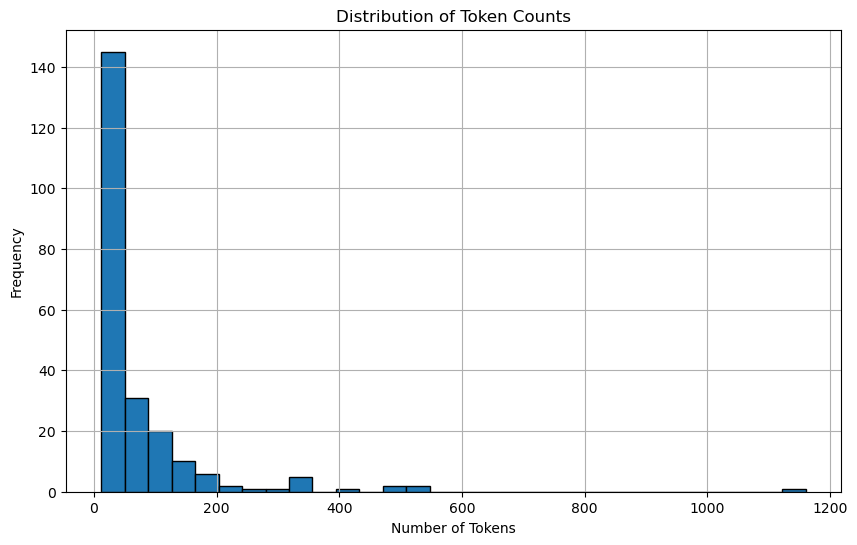

count     227.000000
mean       74.634361
std       114.830862
min        12.000000
25%        24.000000
50%        36.000000
75%        80.000000
max      1160.000000
Name: num_tokens, dtype: float64


In [22]:
# import spacy
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load spacy's model for tokenization (e.g., en_core_web_sm)
# nlp = spacy.load("en_core_web_sm")

# # Calculate number of tokens for each row using spacy
# df['num_tokens'] = df['speech'].apply(lambda x: len(nlp(x)))

# # Plot the distribution of token counts
# plt.figure(figsize=(10, 6))
# plt.hist(df['num_tokens'], bins=30, edgecolor='black')
# plt.title('Distribution of Token Counts')
# plt.xlabel('Number of Tokens')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

# # Display the token count distribution summary
# print(df['num_tokens'].describe())


In [85]:
# model_choice = "gpt-4o-mini"

# # System prompt for the assistant's role
# SYSTEM_PROMPT = ("You are a helpful research assistant helping to analyze congressional hearing transcripts to determine whether they contain a discussion of empirical evidence."
#                  "Empirical evidence is information that is derived from experience, observation, or experimentation."
#                  "answer the questions you are given and don't return anything else but the answer."
#                 )

# USER_MESSAGE = (
#     "Does the speech mention empirical evidence? Answer only Yes or No."
#     "Cite all specific mentions of empirical evidence in the speech. Give full quotes. seperate each quote by ***** "
#     "Classify each specific mention of empirical evidence into one of the following categories: Monetary, Causal Impact, Testimonial, Statistical, Other. seperate each one by *****"
#     "Example output format:\n"
#     "*** EMPIRICAL BINARY ***\n"
#     "<Yes or No>\n"
#     "*** EMPIRICAL EVIDENCE QUOTES ***\n"
#     "<quote1 ***** quote2 ***** quote3>\n"
#     "*** EMPIRICAL EVIDENCE CATEGORY ***\n"
#     "<Monetary ***** Testimonial ***** Other>\n"
# )

# # Function to count the number of tokens in the text (you can replace this with actual tokenizer)
# def count_tokens(text):
#     return len(text.split())  # Basic token count, replace with more accurate method if needed

# # Function to split the text into chunks of max_tokens
# def split_into_chunks(text, max_tokens=500):
#     tokens = text.split()
#     return [' '.join(tokens[i:i + max_tokens]) for i in range(0, len(tokens), max_tokens)]

# # Function to send a message to the model
# def send_message(role_messages):
#     response = client.chat.completions.create(
#         model=model_choice,
#         messages=role_messages,
#         temperature=0,
#         max_tokens=500,
#         top_p=1,
#         frequency_penalty=0,
#         presence_penalty=0
#     )
#     return response.choices[0].message.content

# def parse_assistant_response(assistant_content):
#     # Extract the empirical binary part
#     binary_start = assistant_content.find('*** EMPIRICAL BINARY ***') + len('*** EMPIRICAL BINARY ***')
#     binary_end = assistant_content.find('*** EMPIRICAL EVIDENCE QUOTES ***')
#     empirical_binary = assistant_content[binary_start:binary_end].strip()
    
#     # Extract the empirical quotes part
#     quotes_start = assistant_content.find('*** EMPIRICAL EVIDENCE QUOTES ***') + len('*** EMPIRICAL EVIDENCE QUOTES ***')
#     quotes_end = assistant_content.find('*** EMPIRICAL EVIDENCE CATEGORY ***')
#     empirical_quotes = assistant_content[quotes_start:quotes_end].strip().split(" ***** ")
    
#     # Extract the empirical categories part
#     category_start = assistant_content.find('*** EMPIRICAL EVIDENCE CATEGORY ***') + len('*** EMPIRICAL EVIDENCE CATEGORY ***')
#     empirical_category = assistant_content[category_start:].strip().split(" ***** ")
    
#     return empirical_binary, empirical_quotes, empirical_category


# # Function to classify and process the full speech or its chunks
# def classify_full_speech(row):
#     speech = row['speech']
    
#     # Initial system message
#     system_message = {"role": "system", "content": SYSTEM_PROMPT}
    
#     if count_tokens(speech) > 500:
#         # If the speech has more than 500 tokens, split it into chunks
#         chunks = split_into_chunks(speech)
        
#         # Initialize variables to concatenate results
#         concatenated_response = {
#             "empirical_binary": None,
#             "empirical_quotes": [],
#             "empirical_category": []
#         }
        
#         for chunk in chunks:
#             # Create the conversation log for each chunk
#             user_message = {"role": "user", "content": f"{USER_MESSAGE} Speech: {chunk}"}
#             role_messages = [system_message, user_message]
            
#             # Send the chunk to the model and get the response
#             chunk_response = send_message(role_messages)
            
#             # Parse the response for each chunk
#             empirical_binary, empirical_quotes, empirical_category = parse_assistant_response(chunk_response)
            
#             # For the binary, once we get "Yes", we stick to it, assuming we care only for "Yes"
#             if concatenated_response["empirical_binary"] is None or empirical_binary == "Yes":
#                 concatenated_response["empirical_binary"] = empirical_binary
            
#             # Concatenate the quotes and categories
#             concatenated_response["empirical_quotes"].extend(empirical_quotes)
#             concatenated_response["empirical_category"].extend(empirical_category)
        
#         # Return the concatenated response
#         return concatenated_response["empirical_binary"], concatenated_response["empirical_quotes"], concatenated_response["empirical_category"]
    
#     else:
#         # If the speech is less than 500 tokens, process it normally
#         user_message = {"role": "user", "content": f"{USER_MESSAGE} Speech: {speech}"}
#         role_messages = [system_message, user_message]
        
#         # Send the speech to the model
#         full_response = send_message(role_messages)
        
#         # Parse the response and return the result
#         return parse_assistant_response(full_response)

# # Apply the process_speech function to each row in the DataFrame
# def process_speech(row):
#     # Classify the full speech or its chunks
#     empirical_binary, empirical_quotes, empirical_category = classify_full_speech(row)
    
#     # Return the results as a tuple that will be expanded into new columns
#     return empirical_binary, empirical_quotes, empirical_category



In [91]:
# # Apply the function to each row and expand the result into new columns
# df[['empirical_binary', 'empirical_quotes', 'empirical_category']] = df.apply(process_speech, axis=1, result_type='expand')

# df.to_csv(project_path("hearings_testing", f"CHRG-105hhrg38711_classified_fullspeech.csv"), index=False)

# Sentence context approach 

In [34]:
import nltk
from nltk.tokenize import sent_tokenize
import os
import pandas as pd
from openai import OpenAI
import re
from pathlib import Path
import spacy

# System prompt for the assistant's role
SYSTEM_PROMPT = ("You are a helpful research assistant helping to analyze congressional hearing transcripts."
		 "Your goal is to determine whether a speech contains a discussion of empirical evidence."
		"Empirical evidence is information gathered directly or indirectly through observation or experimentation that may be used to confirm or disconfirm a theory or policy, or to help justify, or establish as reasonable, a person’s belief in a given proposition or argument."
		 "Empirical evidence may regard specific events, factors and causes, or more generally relationships between factors such as causality or correlation"
		"Abstract statements such as 'where there is smoke there is fire' are not included."
		"Statements about research to establish facts or descriptions of reality are included."
		"Testimonial statements about the experience of a single person or a handful of people are not included, but large groups may be included."
		"qualitative empirical statements are based on non-quantitative observations, interviews, narratives, or other similar means of analysis"
		"monetary empirical statements refer to facts about the economy, currency, budgets, etc."
		"statistical empirical statements refer to the use of statistics for inference, such as sampling the population, differences between groups, differences between means and medians, and so on"
                 "You will be given a sentence along with a context window of one sentence before and after."
                 "only refer to the <target sentence> in your answers."
                 "answer the questions you are given and don't return anything else but the answer.")

USER_MESSAGE = (
    "Does the <target sentence> mention empirical evidence? Answer only Yes or No."
    "Cite all specific mentions of empirical evidence in the <target sentence>. Give full quotes. separate each quote by ***** "
    "Classify each specific mention of empirical evidence into one of the following categories: Causal, Correlational, Descriptive, Monetary, Statistical, Qualitative, Historical, Other (specify). separate each one by *****"
    "Example output format:\n"
    "*** EMPIRICAL BINARY ***\n"
    "<Yes or No>\n"
    "*** EMPIRICAL EVIDENCE QUOTES ***\n"
    "<quote1 ***** quote2 ***** quote3>\n"
    "*** EMPIRICAL EVIDENCE CATEGORY ***\n"
    "<Monetary ***** Testimonial ***** Other>\n"
)

# Function to count the number of tokens in the text (you can replace this with actual tokenizer)
def count_tokens(text):
    return len(text.split())  # Basic token count, replace with more accurate method if needed

# Function to split the text into chunks of max_tokens
def split_into_chunks(text, max_tokens=500):
    tokens = text.split()
    return [' '.join(tokens[i:i + max_tokens]) for i in range(0, len(tokens), max_tokens)]

# Function to send a message to the model
def send_message(role_messages):
    response = client.chat.completions.create(
        model=model_choice,
        messages=role_messages,
        temperature=0,
        max_tokens=500,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0
    )
    return response.choices[0].message.content

def parse_assistant_response(assistant_content):
    # Extract the empirical binary part
    binary_start = assistant_content.find('*** EMPIRICAL BINARY ***') + len('*** EMPIRICAL BINARY ***')
    binary_end = assistant_content.find('*** EMPIRICAL EVIDENCE QUOTES ***')
    empirical_binary = assistant_content[binary_start:binary_end].strip()
    
    # Extract the empirical quotes part
    quotes_start = assistant_content.find('*** EMPIRICAL EVIDENCE QUOTES ***') + len('*** EMPIRICAL EVIDENCE QUOTES ***')
    quotes_end = assistant_content.find('*** EMPIRICAL EVIDENCE CATEGORY ***')
    empirical_quotes = assistant_content[quotes_start:quotes_end].strip().split(" ***** ")
    
    # Extract the empirical categories part
    category_start = assistant_content.find('*** EMPIRICAL EVIDENCE CATEGORY ***') + len('*** EMPIRICAL EVIDENCE CATEGORY ***')
    empirical_category = assistant_content[category_start:].strip().split(" ***** ")
    
    return empirical_binary, empirical_quotes, empirical_category

# Load the spaCy English model
nlp = spacy.load('en_core_web_sm')

# Function to split the text into sentences using spaCy
def split_into_sentences(text):
    doc = nlp(text)
    return [sent.text for sent in doc.sents]  # Return a list of sentence strings

# Function to create a structured context window of <context_before> <target_sentence> <context_after>
def create_context_window(sentences, index):
    target_sentence = sentences[index]
    
    # Handle first and last sentence cases
    context_before = sentences[index - 1] if index > 0 else ""
    context_after = sentences[index + 1] if index < len(sentences) - 1 else ""
    
    # Return the structured context: <context_before> <target_sentence> <context_after>
    return context_before, target_sentence, context_after

# Updated classify function that processes each sentence with a structured context window
def classify_sentences_with_context(row):
    speech = row['speech']
    
    # Split the speech into sentences
    sentences = split_into_sentences(speech)
    
    rows = []  # To store all the rows for each context window
    
    for i in range(len(sentences)):
        # Create the structured context window for each sentence
        context_before, target_sentence, context_after = create_context_window(sentences, i)
        
        # Build the user message with the structured format
        user_message_content = f"<context_before> {context_before} </context_before> <target_sentence> {target_sentence} </target_sentence> <context_after> {context_after} </context_after>"
        user_message = {"role": "user", "content": f"{USER_MESSAGE} Speech: {user_message_content}"}
        role_messages = [{"role": "system", "content": SYSTEM_PROMPT}, user_message]
        
        # Send the context window to the model and get the response
        response = send_message(role_messages)
        
        # Parse the response for each context window
        empirical_binary, empirical_quotes, empirical_category = parse_assistant_response(response)
        
        # Append a new row for this context window, preserving the original columns
        context_row = row.copy()  # Copy the original row to preserve other columns
        context_row['context_before'] = context_before
        context_row['target_sentence'] = target_sentence
        context_row['context_after'] = context_after
        context_row['empirical_binary'] = empirical_binary
        context_row['empirical_quotes'] = " ***** ".join(empirical_quotes)
        context_row['empirical_category'] = " ***** ".join(empirical_category)
        
        rows.append(context_row)
    
    # Return the rows for this speech (one row for each context window)
    return rows

# Function that processes each speech and expands the DataFrame
def process_speech_df(df):
    expanded_rows = []
    
    # Process each row in the original DataFrame
    for index, row in df.iterrows():
        new_rows = classify_sentences_with_context(row)
        expanded_rows.extend(new_rows)
    
    # Create a new DataFrame from the expanded rows
    expanded_df = pd.DataFrame(expanded_rows)
    return expanded_df

In [38]:
# few shot
import json

# Load the file into a Python object
with open(project_path("hearings_testing","few_shot_examples.json"), 'r') as f:
    FEW_SHOT_EXAMPLES = json.load(f)

def send_message_with_few_shot(role_messages):
    full_messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    full_messages.extend(FEW_SHOT_EXAMPLES)
    full_messages.extend(role_messages)

    response = client.chat.completions.create(
        model=model_choice,
        messages=full_messages,
        temperature=0,
        max_tokens=500,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0
    )
    return response.choices[0].message.content


def classify_sentences_with_context_fewshot(row):
    speech = row['speech']
    sentences = split_into_sentences(speech)
    rows = []

    for i in range(len(sentences)):
        context_before, target_sentence, context_after = create_context_window(sentences, i)
        user_message_content = (
            f"<context_before> {context_before} </context_before> "
            f"<target_sentence> {target_sentence} </target_sentence> "
            f"<context_after> {context_after} </context_after>"
        )
        user_message = {"role": "user", "content": f"{USER_MESSAGE} Speech: {user_message_content}"}
        role_messages = [user_message]

        # Use the few-shot function here
        response = send_message_with_few_shot(role_messages)

        empirical_binary, empirical_quotes, empirical_category = parse_assistant_response(response)

        context_row = row.copy()
        context_row['context_before'] = context_before
        context_row['target_sentence'] = target_sentence
        context_row['context_after'] = context_after
        context_row['empirical_binary'] = empirical_binary
        context_row['empirical_quotes'] = " ***** ".join(empirical_quotes)
        context_row['empirical_category'] = " ***** ".join(empirical_category)

        rows.append(context_row)

    return rows

def process_speech_df_fewshot(df):
    expanded_rows = []
    
    # Process each row in the original DataFrame
    for index, row in df.iterrows():
        new_rows = classify_sentences_with_context_fewshot(row)
        expanded_rows.extend(new_rows)
    
    # Create a new DataFrame from the expanded rows
    expanded_df = pd.DataFrame(expanded_rows)
    return expanded_df

In [44]:
# Generate the hearing list dynamically
hearing_list = [
    f[:-4] for f in os.listdir(project_path("hearings_testing"))
    if f.startswith("CHRG") and f.endswith(".csv") and "_classified_sentcontext" not in f
]

#model_choice = "gpt-4o-mini"
model_choice = "gpt-4o"

for hearing in hearing_list:
    output_file = project_path("hearings_testing", f"{hearing}_classified_sentcontext_{model_choice}.csv")
    
    # Check if the file already exists
    if os.path.exists(output_file):
        print(f"Skipping {hearing}: already processed.")
        continue
    
    print(f"Processing {hearing}...")
    
    # Load the CSV file
    df = pd.read_csv(project_path("hearings_testing", f"{hearing}.csv"))
    
    # Process the DataFrame to expand rows based on sentence context windows
    expanded_df = process_speech_df_fewshot(df)
    
    # Save the processed DataFrame
    expanded_df.to_csv(output_file, index=False)
    print(f"Saved {output_file}.")

Processing CHRG-105hhrg38711...
Saved G:\My Drive\Work\Working Papers\evidence in legislatures_Barak-Corren&Ash\hearings_testing\CHRG-105hhrg38711_classified_sentcontext_gpt-4o.csv.
Processing CHRG-109hhrg98564...
Saved G:\My Drive\Work\Working Papers\evidence in legislatures_Barak-Corren&Ash\hearings_testing\CHRG-109hhrg98564_classified_sentcontext_gpt-4o.csv.
Processing CHRG-111hhrg62681...
Saved G:\My Drive\Work\Working Papers\evidence in legislatures_Barak-Corren&Ash\hearings_testing\CHRG-111hhrg62681_classified_sentcontext_gpt-4o.csv.
Processing CHRG-111hhrg56421...
Saved G:\My Drive\Work\Working Papers\evidence in legislatures_Barak-Corren&Ash\hearings_testing\CHRG-111hhrg56421_classified_sentcontext_gpt-4o.csv.
Processing CHRG-111hhrg49951...
Saved G:\My Drive\Work\Working Papers\evidence in legislatures_Barak-Corren&Ash\hearings_testing\CHRG-111hhrg49951_classified_sentcontext_gpt-4o.csv.
Processing CHRG-105hhrg41799...
Saved G:\My Drive\Work\Working Papers\evidence in legislat

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

# Sentence window approach 

In [124]:
# import random
# import nltk
# from nltk.tokenize import sent_tokenize
# # Ensure you have the NLTK sentence tokenizer available
# # nltk.download('punkt')

# model_choice = "gpt-4o-mini"

# # System prompt for the assistant's role
# SYSTEM_PROMPT = ("You are a helpful research assistant helping to analyze congressional hearing transcripts to determine whether they contain a discussion of empirical evidence."
#                  "Empirical evidence is information that is derived from experience, observation, or experimentation."
#                  "answer the questions you are given and don't return anything else but the answer."
#                 )

# USER_MESSAGE = (
#     "Does the speech mention empirical evidence? Answer only Yes or No."
#     "Cite all specific mentions of empirical evidence in the speech. Give full quotes. seperate each quote by ***** "
#     "Classify each specific mention of empirical evidence into one of the following categories: Monetary, Causal Impact, Testimonial, Statistical, Other. seperate each one by *****"
#     "Example output format:\n"
#     "*** EMPIRICAL BINARY ***\n"
#     "<Yes or No>\n"
#     "*** EMPIRICAL EVIDENCE QUOTES ***\n"
#     "<quote1 ***** quote2 ***** quote3>\n"
#     "*** EMPIRICAL EVIDENCE CATEGORY ***\n"
#     "<Monetary ***** Testimonial ***** Other>\n"
# )

# SENT_SMPL_N = 5
# SENT_WINDOW_N = 4

# # Function to count the number of tokens in the text (you can replace this with actual tokenizer)
# def count_tokens(text):
#     return len(text.split())  # Basic token count, replace with more accurate method if needed

# # Function to split the text into chunks of max_tokens
# def split_into_chunks(text, max_tokens=500):
#     tokens = text.split()
#     return [' '.join(tokens[i:i + max_tokens]) for i in range(0, len(tokens), max_tokens)]

# # Function to send a message to the model
# def send_message(role_messages):
#     response = client.chat.completions.create(
#         model=model_choice,
#         messages=role_messages,
#         temperature=0,
#         max_tokens=500,
#         top_p=1,
#         frequency_penalty=0,
#         presence_penalty=0
#     )
#     return response.choices[0].message.content

# # Function to split the text into sentences
# def split_into_sentences(text):
#     return sent_tokenize(text)

# # Function to sample batches of 4 consecutive sentences from the text
# def sample_consecutive_sentences(sentences, num_samples=SENT_SMPL_N, batch_size=SENT_WINDOW_N):
#     # Ensure there are enough sentences to sample from
#     if len(sentences) <= batch_size:
#         return [sentences]  # If the text is too short, return the whole text as one batch
    
#     # Sample 5 times, ensuring we don't sample from the end
#     samples = []
#     max_start = len(sentences) - batch_size
#     for _ in range(num_samples):
#         start_idx = random.randint(0, max_start)
#         samples.append(sentences[start_idx:start_idx + batch_size])
    
#     return samples

# def classify_full_speech(row):
#     speech = row['speech']
    
#     # Split the speech into sentences
#     sentences = split_into_sentences(speech)
    
#     # If there are more than 4 sentences, apply the sliding window approach
#     if len(sentences) > SENT_WINDOW_N:
#         # Sample 5 batches of 4 consecutive sentences
#         sampled_batches = sample_consecutive_sentences(sentences, num_samples=SENT_SMPL_N)
        
#         rows = []  # To store all the rows for this speech
        
#         for batch in sampled_batches:
#             batch_text = ' '.join(batch)
#             user_message = {"role": "user", "content": f"{USER_MESSAGE} Speech: {batch_text}"}
#             role_messages = [{"role": "system", "content": SYSTEM_PROMPT}, user_message]
            
#             # Send the batch to the model and get the response
#             batch_response = send_message(role_messages)
            
#             # Parse the response for each batch
#             empirical_binary, empirical_quotes, empirical_category = parse_assistant_response(batch_response)
            
#             # Append a new row for this batch, preserving the original columns
#             batch_row = row.copy()  # Copy the original row to preserve other columns
#             batch_row['speech_batch'] = batch_text
#             batch_row['empirical_binary'] = empirical_binary
#             batch_row['empirical_quotes'] = " ***** ".join(empirical_quotes)
#             batch_row['empirical_category'] = " ***** ".join(empirical_category)
            
#             rows.append(batch_row)
        
#         # Return the rows for this speech (one row for each batch)
#         return rows
    
#     else:
#         # If the speech is 4 sentences or less, process it normally
#         user_message = {"role": "user", "content": f"{USER_MESSAGE} Speech: {speech}"}
#         role_messages = [{"role": "system", "content": SYSTEM_PROMPT}, user_message]
        
#         # Send the speech to the model
#         full_response = send_message(role_messages)
        
#         # Parse the response and return one row (no batch sampling)
#         empirical_binary, empirical_quotes, empirical_category = parse_assistant_response(full_response)
        
#         # Create a row preserving the original columns
#         row['speech_batch'] = speech
#         row['empirical_binary'] = empirical_binary
#         row['empirical_quotes'] = " ***** ".join(empirical_quotes)
#         row['empirical_category'] = " ***** ".join(empirical_category)
        
#         return [row]  # Return as a list to keep consistent with the batch case

# # Function that processes each speech and expands the DataFrame
# def process_speech_df(df):
#     # To store the new rows
#     expanded_rows = []
    
#     # Process each row in the original DataFrame
#     for index, row in df.iterrows():
#         new_rows = classify_full_speech(row)
#         expanded_rows.extend(new_rows)
    
#     # Create a new DataFrame from the expanded rows
#     expanded_df = pd.DataFrame(expanded_rows)
#     return expanded_df


In [10]:
# # Process the DataFrame to expand rows based on sentence batches
# expanded_df = process_speech_df(df)

# expanded_df

# sentence level approach

In [15]:
# # model_choice = "gpt-3.5-turbo"
# # model_choice = "gpt-4"
# model_choice = "gpt-4o-mini"

# def classify_sentence(sentence):
#     response = client.chat.completions.create(
#       model=model_choice,
#       messages=[
#         {
#           "role": "system",
#           "content": [
#             {
#               "type": "text",
#               # "text": "\"You are a helpful research assistant, helping to analyze congressional hearing transcripts to determine whether they contain a discussion of empirical evidence. \" \"Empirical evidence is information that is derived from experience, observation, or experimentation. Please answer the following questions and return only the answer:\\n\" f\"1. Does the sentence mention or cite empirical evidence? Answer only Yes or No.\\n\" f\"2. Classify the sentence into one or more categories out of the following: No Evidence, Monetary, Causal Impact, Testimonial, Statistical, Other.\\n\" f\"3. Please rank the sentence on the following scale: 1-not analytical at all, 2-not very analytical, 3-neutral, 4-somewhat analytical, 5-very analytical.\\n\" f\"4. Does the text mention constitutional issues or analysis?\\n\""
#             "text": "\"You are a helpful research assistant, helping to analyze congressional hearing transcripts to determine whether they contain a discussion of empirical evidence. \" \"Empirical evidence is information that is derived from experience, observation, or experimentation. Please answer the following questions and return only the answer:\\n\" f\"1. Does the sentence mention or cite empirical evidence? Answer only Yes or No.\\n\" f\"2. How confident is your answer between 1-not confident at all and 5-very confident? \\n\" f\"3. Classify the sentence into one or more categories out of the following: No Evidence, Monetary, Causal Impact, Testimonial, Statistical, Other.\\n\" f\"4. Please rank the sentence on the following scale: 1-not analytical at all, 2-not very analytical, 3-neutral, 4-somewhat analytical, 5-very analytical.\\n\" f\"5. Does the text mention constitutional issues or analysis?\\n\""
#             }
#           ]
#         },
#         {
#           "role": "user",
#           "content": [
#             {
#               "type": "text",
#               "text": f"Sentence: '{sentence}'"
#             }
#           ]
#         }
#       ],
#       temperature=0,
#       max_tokens=256,
#       top_p=1,
#       frequency_penalty=0,
#       presence_penalty=0
#     )
    
#     return response.choices[0].message.content

# def split_output(response):
#     # Remove the surrounding single quotes
#     cleaned_string = response.strip("'")
    
#     # Split the string based on newlines
#     lines = cleaned_string.split('\n')

#     result = []
#     for line in lines:
#         parts = line.split('. ', 1)
#         if len(parts) == 2:
#             result.append(parts[1])
#         else:
#             result.append('')  # Add an empty string if the format is incorrect
#     # Ensure the result has exactly four elements
#     # while len(result) < 4:
#     while len(result) < 5:
#         result.append('')
#     return result

# def classify_and_split(sentence):
#     classified_sentence = classify_sentence(sentence)
#     split_result = split_output(classified_sentence)
#     return split_result

# def split_and_classify_speeches(df):
#     # Function to split speeches into sentences while preserving all other columns
#     new_df = pd.concat(df.apply(split_speech_to_sentences, axis=1).tolist(), ignore_index=True)
    
#     # Classify each sentence and add the results to the DataFrame
#     classifications = new_df['sentence'].apply(classify_and_split)
#     classifications_df = pd.DataFrame(classifications.tolist(), columns=['Empirical Evidence', 'Confidence', 'Category', 'Analytical Ranking', 'Constitutional Issues'])
#     final_df = pd.concat([new_df, classifications_df], axis=1)
#     return final_df

# classified_df = df.loc[:,['file_name','speech','congress','committee_code2','title','file_name','thomas_name','govtrack','rownumber']]
# classified_df = split_and_classify_speeches(classified_df)

# classified_df['Analytical Ranking'] = classified_df['Analytical Ranking'].str.replace(r'\D', '', regex=True)

# classified_df.to_csv(project_path("hearings_testing", f"CHRG-105hhrg38711_classified_{model_choice}.csv"), index=False)

# classified_df['Empirical Evidence'] = classified_df['Empirical Evidence'].str.strip()
# classified_df['Empirical Evidence'] = classified_df['Empirical Evidence'].map({'Yes': 1, 'No': 0})

# Start Analysis

## look at distribution

In [ ]:
# classified_df = pd.read_csv(project_path("hearings_testing","CHRG-105hhrg38711_classified_gpt-4o-mini.csv"))

In [96]:
classified_df.groupby('thomas_name')['Empirical Evidence'].mean().reset_index()

,thomas_name,Empirical Evidence
0,"Gilman, Benjamin",0.157895
1,"Horn, Stephen",0.022727
2,"Pappas, Michael",0.000000
3,"Ros-Lehtinen, Ileana",0.000000
4,"Sanders, Bernard",0.034314
5,"Sessions, Pete",0.000000
6,"Shays, Christopher",0.018789
7,"Snowbarger, Vince",0.000000
8,"Towns, Edolphus",0.016949


In [100]:
grouped_df = classified_df.groupby('rownumber')['Empirical Evidence'].mean().reset_index()

summary_statistics = grouped_df['Empirical Evidence'].describe()
print(summary_statistics)

count    227.000000
mean       0.013664
std        0.066112
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.500000
Name: Empirical Evidence, dtype: float64


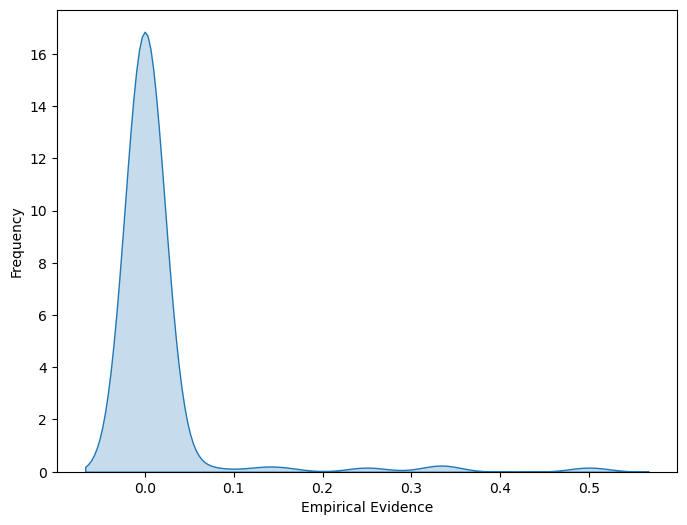

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution using Seaborn
plt.figure(figsize=(8, 6))
sns.kdeplot(grouped_df['Empirical Evidence'], fill=True)
plt.xlabel('Empirical Evidence')
plt.ylabel('Frequency')
plt.show()

C:\Users\mitha\AppData\Local\Temp\ipykernel_26204\3600030751.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels)


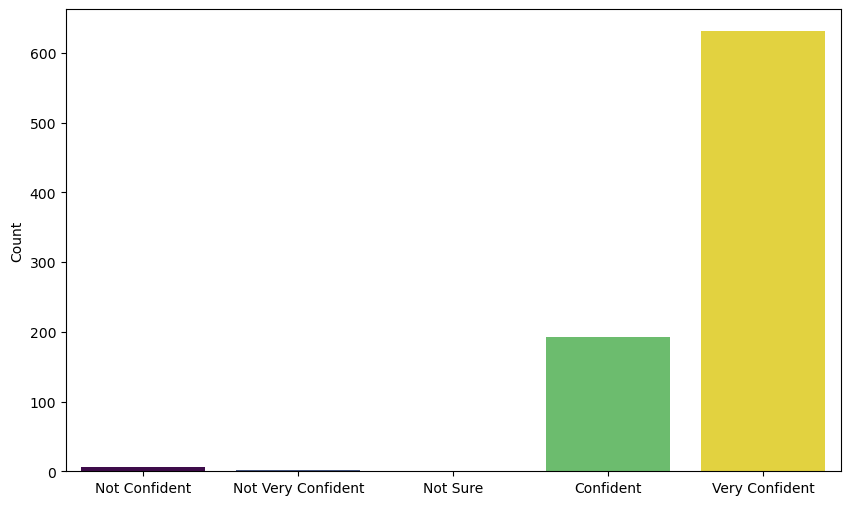

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

variable = 'Analyitic'

# Custom x-axis labels
custom_labels = ['Not Confident', 'Not Very Confident', 'Not Sure', 'Confident', 'Very Confident']

# Plotting the bar plot using seaborn
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=variable, hue = variable, data=classified_df, palette='viridis', dodge=False, legend=False)

# Set custom x-axis labels
ax.set_xticklabels(custom_labels)
ax.set_xlabel('')  # Set to an empty string
ax.set_ylabel('Count')
# ax.set_title('Distribution of Categories')

plt.show()


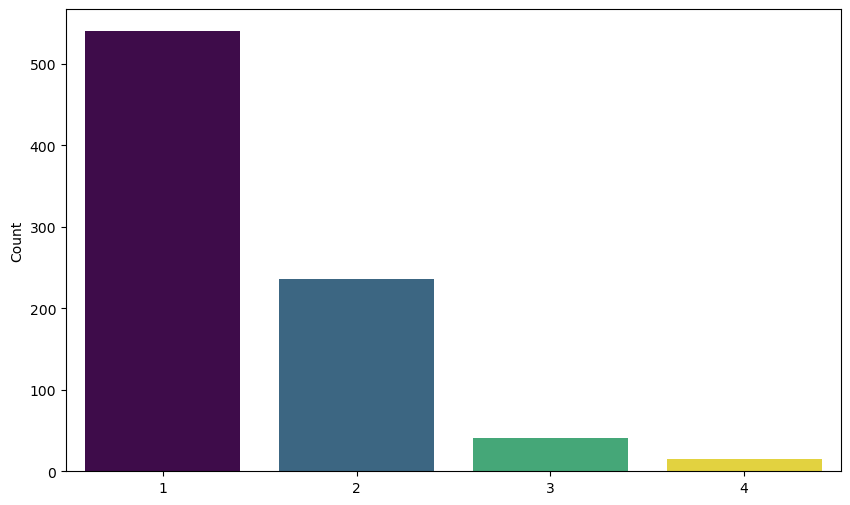

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

variable = 'Analytical Ranking'

# Custom x-axis labels
# custom_labels = ['Not Confident', 'Not Very Confident', 'Not Sure', 'Confident', 'Very Confident']

# Plotting the bar plot using seaborn
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=variable, hue = variable, data=classified_df, palette='viridis', dodge=False, legend=False)

# Set custom x-axis labels
# ax.set_xticklabels(custom_labels)
ax.set_xlabel('')  # Set to an empty string
ax.set_ylabel('Count')
# ax.set_title('Distribution of Categories')

plt.show()


In [140]:
# Clean the 'Category' column: strip spaces and convert to lowercase
classified_df['Category_cleaned'] = classified_df['Category'].str.replace(' ', '').str.lower()

# Split the cleaned 'Category' column by comma
classified_df['Category_split'] = classified_df['Category_cleaned'].str.split(',')

# Get the list of all unique categories
unique_categories = set()
classified_df['Category_split'].apply(unique_categories.update)

# Create one-hot encoded columns
for category in unique_categories:
    classified_df[f'category_{category}'] = classified_df['Category_split'].apply(lambda x: int(category in x))

# Drop the temporary columns
classified_df.drop(['Category_cleaned', 'Category_split'], axis=1, inplace=True)

C:\Users\mitha\AppData\Local\Temp\ipykernel_26204\3724200626.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Share', data=category_shares_df, palette='viridis')


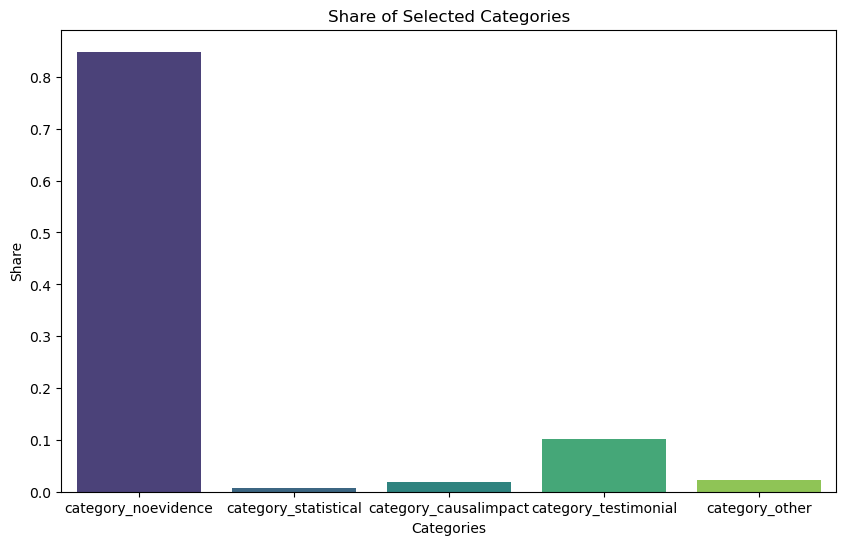

In [166]:
# Specify the columns you want to plot
columns_to_plot = ['category_noevidence','category_statistical','category_causalimpact','category_testimonial', 'category_other']

# Calculate the sum of the specified columns
category_sums = classified_df[columns_to_plot].sum()

# Normalize the sums to get the share
total_sum = category_sums.sum()
category_shares = category_sums / total_sum

# Convert the shares to a DataFrame for seaborn
category_shares_df = category_shares.reset_index()
category_shares_df.columns = ['Category', 'Share']

# Plot the distribution using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Share', data=category_shares_df, palette='viridis')
plt.title('Share of Selected Categories')
plt.xlabel('Categories')
plt.ylabel('Share')
plt.xticks(rotation=0)
plt.show()

C:\Users\mitha\AppData\Local\Temp\ipykernel_26204\769625545.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Share', data=category_shares_df, palette='viridis')


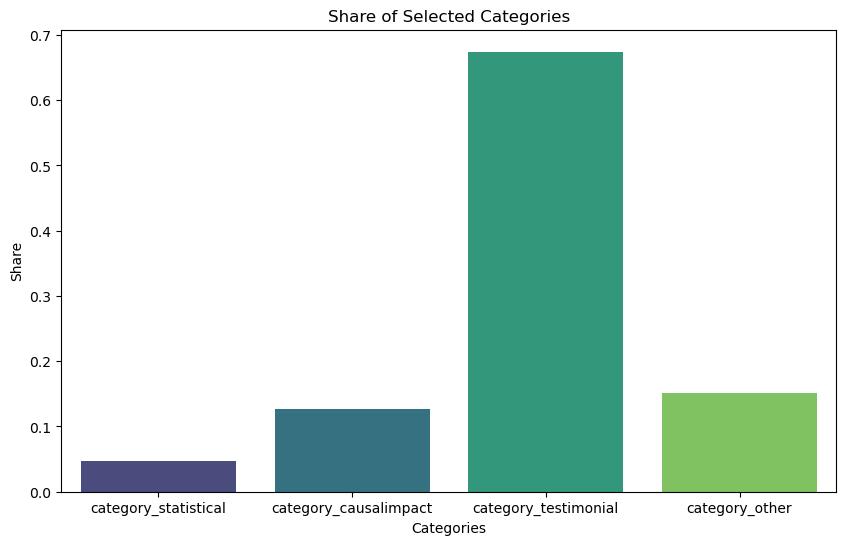

In [168]:
# Specify the columns you want to plot
columns_to_plot = ['category_statistical','category_causalimpact','category_testimonial', 'category_other']

# Calculate the sum of the specified columns
category_sums = classified_df[columns_to_plot].sum()

# Normalize the sums to get the share
total_sum = category_sums.sum()
category_shares = category_sums / total_sum

# Convert the shares to a DataFrame for seaborn
category_shares_df = category_shares.reset_index()
category_shares_df.columns = ['Category', 'Share']

# Plot the distribution using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Share', data=category_shares_df, palette='viridis')
plt.title('Share of Selected Categories')
plt.xlabel('Categories')
plt.ylabel('Share')
plt.xticks(rotation=0)
plt.show()

## Inter rater agreement on sample

In [16]:
sample_gpt = pd.read_csv(project_path("hearings_testing","sample_comparison","gpt_4o.csv"))
sample_rater1 = pd.read_csv(project_path("hearings_testing","sample_comparison","amit.csv"))
sample_rater2 = pd.read_csv(project_path("hearings_testing","sample_comparison","netta.csv"))


sample_gpt['Empirical Evidence'] = sample_gpt['Empirical Evidence'].str.strip().str.lower().apply(lambda x: 1 if x == 'yes' else 0)
sample_rater2['Empirical Evidence'] = sample_rater2['Empirical Evidence'].apply(lambda x: 1 if x == 'Yes' else 0)

# common columns and unique columns
common_columns = ['file_name', 'speech','congress','committee_code2','title','thomas_name','govtrack','rownumber','sentence']
unique_columns = ['Empirical Evidence', 'Confidence','Category','Analytical Ranking','Constitutional Issues']

# Rename unique columns in each dataframe
sample_rater1_renamed = sample_rater1.rename(columns={col: f"{col}_rater1" for col in unique_columns})
sample_rater2_renamed = sample_rater2.rename(columns={col: f"{col}_rater2" for col in unique_columns})
sample_gpt_renamed = sample_gpt.rename(columns={col: f"{col}_gpt" for col in unique_columns})

# Merge the DataFrames on the common columns
merged_df = sample_rater1_renamed.merge(sample_rater2_renamed, on=common_columns) \
                                .merge(sample_gpt_renamed, on=common_columns)

In [7]:
# pd.set_option('display.max_colwidth', None)

# merged_df


In [61]:
kappa_score_binary = cohen_kappa_score(merged_df['Empirical Evidence_rater1'], merged_df['Empirical Evidence_rater2'])

print(round(kappa_score_binary,2))

0.56


## evaluate GPT against our baseline

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

label =  merged_df['Empirical Evidence_rater2']  # Ground truth
gpt = merged_df['Empirical Evidence_gpt']  # Predictions

# Confusion Matrix
cm = confusion_matrix(label, gpt)
print("Confusion Matrix:")
print(cm)

# Calculate metrics
accuracy = accuracy_score(label, gpt)
precision = precision_score(label, gpt)
recall = recall_score(label, gpt)
f1 = f1_score(label, gpt)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Confusion Matrix:
[[58  5]
 [12 16]]
Accuracy: 0.81
Precision: 0.76
Recall: 0.57
F1 Score: 0.65


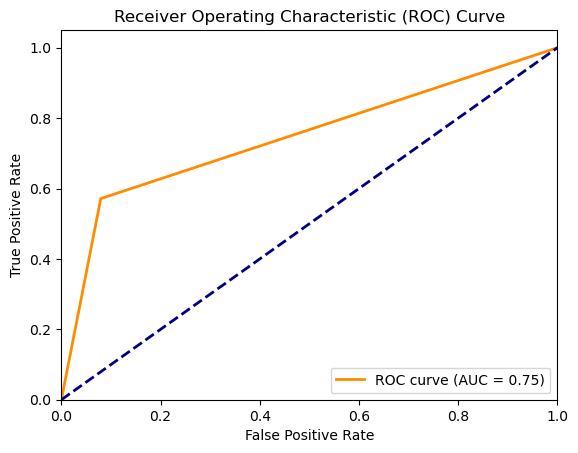

In [77]:
# Calculate probabilities for ROC curve
fpr, tpr, thresholds = roc_curve(label, gpt)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [101]:
# compare confidence?
label =  merged_df['Confidence_rater1']  # Ground truth
gpt = merged_df['Confidence_gpt']  # Predictions

kappa_score_binary = cohen_kappa_score(label, gpt)

print(f"Confidence agreement: {kappa_score_binary:.2f}")

# compare analytical ranking?
label =  merged_df['Analytical Ranking_rater1']  # Ground truth
gpt = merged_df['Analytical Ranking_gpt']  # Predictions

kappa_score_binary = cohen_kappa_score(label, gpt)

print(f"Analytical Ranking agreement: {kappa_score_binary:.2f}")

Confidence agreement: 0.35
Analytical Ranking agreement: 0.37


In [99]:
# Initialize an empty DataFrame
gpt_df = pd.DataFrame()

# Loop through the list of file names
for file_name in hearing_list:
        # Load each file into a DataFrame
    temp_df = pd.read_csv(project_path("hearings_testing", f"{file_name}_classified_sentcontext_gpt-4o.csv"))
        
        # Append to the main DataFrame
    gpt_df = pd.concat([gpt_df, temp_df], ignore_index=True)

gpt_df = gpt_df.sort_values(by=['file_name', 'target_sentence']).reset_index(drop=True)
label_df = label_df.sort_values(by=['file_name', 'target_sentence']).reset_index(drop=True)

merged_df = pd.merge(label_df, gpt_df, on="target_sentence", suffixes=('_ra', '_gpt'))


print(label_df['empirical_binary'].value_counts())



empirical_binary
0    1720
1     225
Name: count, dtype: int64


In [29]:
hearing_list = ['CHRG-109hhrg98564', 'CHRG-105hhrg38711', 'CHRG-111hhrg62681']

label_df = pd.read_csv(project_path("hearings_testing", "sample_comparison","RA_merged_with_agreement.csv"))

label_df = label_df.rename(columns={'file_name_rater1': 'file_name'})

# Initialize an empty DataFrame
gpt_df = pd.DataFrame()

# Loop through the list of file names
for file_name in hearing_list:
        # Load each file into a DataFrame
    temp_df = pd.read_csv(project_path("hearings_testing", f"{file_name}_classified_sentcontext_gpt-4o.csv"))
        
        # Append to the main DataFrame
    gpt_df = pd.concat([gpt_df, temp_df], ignore_index=True)

gpt_df = gpt_df.sort_values(by=['file_name', 'target_sentence']).reset_index(drop=True)
label_df = label_df.sort_values(by=['file_name', 'target_sentence']).reset_index(drop=True)

merged_df = pd.merge(label_df, gpt_df, on="target_sentence", suffixes=('_ra', '_gpt'))

merged_df['empirical_binary_gpt'] = merged_df['empirical_binary_gpt'].str.strip().str.lower().apply(lambda x: 1 if x in ('yes', 'y') else 0)

# Simple agreement
agreement = (merged_df['empirical_binary_ra'] == merged_df['empirical_binary_gpt']).mean() * 100

disagreement = (merged_df['empirical_binary_ra'] != merged_df['empirical_binary_gpt']).mean() * 100
# Cohen's Kappa
kappa = cohen_kappa_score(merged_df['empirical_binary_ra'], merged_df['empirical_binary_gpt'])

sum_ra = merged_df['empirical_binary_ra'].mean()
sum_gpt = merged_df['empirical_binary_gpt'].mean()


print(f"  Agreement: {agreement:.2f}%")
print(f"  Disagreement: {disagreement:.2f}%")
print(f"  Cohen's Kappa: {kappa:.2f}")
print(f" Sum Human Labels: {sum_ra:.2f}")
print(f" Sum GPT: {sum_gpt:.2f}")
print("\n")

label =  merged_df['empirical_binary_ra']  # Ground truth
gpt = merged_df['empirical_binary_gpt']  # Predictions

# Confusion Matrix
cm = confusion_matrix(label, gpt)
print("Confusion Matrix:")
print(cm)

# Calculate metrics
accuracy = accuracy_score(label, gpt)
precision = precision_score(label, gpt)
recall = recall_score(label, gpt)
f1 = f1_score(label, gpt)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


# Calculate probabilities for ROC curve
fpr, tpr, thresholds = roc_curve(label, gpt)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\mitha\\Documents\\empirical_evidence_corren\\hearings_testing\\CHRG-109hhrg98564_classified_sentcontext_gpt-4o.csv'

In [85]:
merged_df['empirical_binary_gpt'].sum()/len(merged_df)

0.6881720430107527

# inter-rater agreement for RA raters

In [25]:
# Function to calculate agreement and disagreement
def calculate_agreement(merged_df, col):
    # Simple agreement
    agreement = (merged_df[f'{col}_rater1'] == merged_df[f'{col}_rater2']).mean() * 100
    # Simple disagreement
    disagreement = (merged_df[f'{col}_rater1'] != merged_df[f'{col}_rater2']).mean() * 100
    # Cohen's Kappa
    kappa = cohen_kappa_score(merged_df[f'{col}_rater1'], merged_df[f'{col}_rater2'])

    sum_rater1 = merged_df[f'{col}_rater1'].mean()
    sum_rater2 = merged_df[f'{col}_rater2'].mean()

    return agreement, disagreement, kappa, sum_rater1, sum_rater2


def output_binary_agreement(merged_df):
    # Clean and convert 'empirical_binary' columns
    merged_df['empirical_binary_rater1'] = merged_df['empirical_binary_rater1'].str.strip().str.lower().apply(lambda x: 1 if x in ('yes', 'y') else 0)
    merged_df['empirical_binary_rater2'] = merged_df['empirical_binary_rater2'].str.strip().str.lower().apply(lambda x: 1 if x in ('yes', 'y') else 0)

    # Calculate and print agreement, disagreement, and kappa
    agreement, disagreement, kappa, sum_rater1, sum_rater2 = calculate_agreement(merged_df, "empirical_binary")
    print(f"  Agreement: {agreement:.2f}%")
    print(f"  Disagreement: {disagreement:.2f}%")
    print(f"  Cohen's Kappa: {kappa:.2f}")
    print(f" Sum Rater 1: {sum_rater1:.2f}")
    print(f" Sum Rater 2: {sum_rater2:.2f}")
    print("\n")


# Function to compare the two columns
def output_category_agreement(df):
    disagreements = []  # Collect disagreements here
    col = 'empirical_category'
    col1 = f'{col}_rater1'
    col2 = f'{col}_rater2'

    def process_text_column(text):
        # Ensure the value is a string, or treat it as empty
        if not isinstance(text, str):
            return set()  # Treat non-string as empty
        # Convert to lowercase, split by comma, and strip whitespace
        return set(item.strip().lower() for item in text.split(','))


    def compare_and_collect(row):
        set1 = process_text_column(row[col1])
        set2 = process_text_column(row[col2])
        # Compare sets
        if not set1 and not set2:
            return 1  # Both empty
        if (not set1 and set2) or (set1 and not set2) or set1 != set2:
            # Collect disagreement
            disagreements.append((row['target_sentence'], set1, set2))
            return 0
        return 1

    df['comparison_agreement'] = df.apply(compare_and_collect, axis=1)
    
    # Calculate and print category agreement percentage
    category_agreement = df['comparison_agreement'].mean() * 100
    print(f"Category Agreement: {category_agreement:.2f}%")

    # Print disagreements after agreement percentage
    for target_sentence, set1, set2 in disagreements:
        print(f"Disagreement in '{target_sentence}':")
        print(f"  Rater 1 categories: {', '.join(set1) if set1 else 'None'}")
        print(f"  Rater 2 categories: {', '.join(set2) if set2 else 'None'}")
        print("-" * 50)


def sample_compare(merged_df):
    label =  merged_df['empirical_binary_rater1']  # Ground truth
    gpt = merged_df['empirical_binary_rater2']  # Predictions
    
    # Confusion Matrix
    cm = confusion_matrix(label, gpt)
    print("Confusion Matrix:")
    print(cm)
    
    # Calculate metrics
    accuracy = accuracy_score(label, gpt)
    precision = precision_score(label, gpt)
    recall = recall_score(label, gpt)
    f1 = f1_score(label, gpt)
    
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    
    
    # Calculate probabilities for ROC curve
    fpr, tpr, thresholds = roc_curve(label, gpt)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    return roc_auc

In [31]:
for hearing in hearing_list:
    print(hearing)
    
    # Load the CSV files
    df_rater1 = pd.read_csv(project_path("hearings_testing", "RA", f"{hearing}_classified_noam.csv"))
    df_rater2 = pd.read_csv(project_path("hearings_testing", "RA", f"{hearing}_classified_daniel.csv"))

    # Drop NA values and reset indices
    df_rater1 = df_rater1.dropna(subset=['empirical_binary'])
    df_rater2 = df_rater2.dropna(subset=['empirical_binary'])

    # Merge on common rows based on a unique identifier, e.g., "rownumber"
    # Adjust the identifier column if necessary
    merged_df = pd.merge(df_rater1, df_rater2, on="target_sentence", suffixes=('_rater1', '_rater2'))

    # Check if there are common rows to compare
    if merged_df.empty:
        print(f"No common rows found for {hearing}. Skipping.")
        continue

    output_binary_agreement(merged_df)
    #output_category_agreement(merged_df)

CHRG-109hhrg98564
  Agreement: 90.11%
  Disagreement: 9.89%
  Cohen's Kappa: 0.44
 Sum Rater 1: 0.13
 Sum Rater 2: 0.07


CHRG-105hhrg38711
  Agreement: 84.64%
  Disagreement: 15.36%
  Cohen's Kappa: 0.35
 Sum Rater 1: 0.13
 Sum Rater 2: 0.15


CHRG-111hhrg62681
  Agreement: 88.86%
  Disagreement: 11.14%
  Cohen's Kappa: 0.42
 Sum Rater 1: 0.14
 Sum Rater 2: 0.08




CHRG-105hhrg38711
  Agreement: 85.30%
  Disagreement: 14.70%
  Cohen's Kappa: 0.16
 Sum Rater 1: 0.15
 Sum Rater 2: 0.03


Confusion Matrix:
[[828  13]
 [133  19]]
Accuracy: 0.85
Precision: 0.59
Recall: 0.12
F1 Score: 0.21


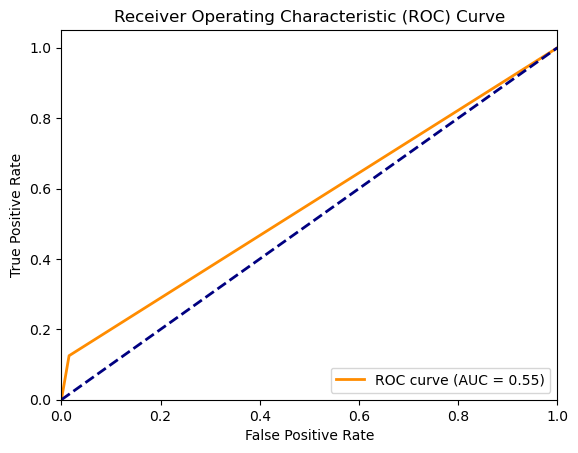

Mean of gpt4: 55.477
CHRG-109hhrg98564
  Agreement: 93.69%
  Disagreement: 6.31%
  Cohen's Kappa: 0.29
 Sum Rater 1: 0.07
 Sum Rater 2: 0.02


Confusion Matrix:
[[512   3]
 [ 32   8]]
Accuracy: 0.94
Precision: 0.73
Recall: 0.20
F1 Score: 0.31


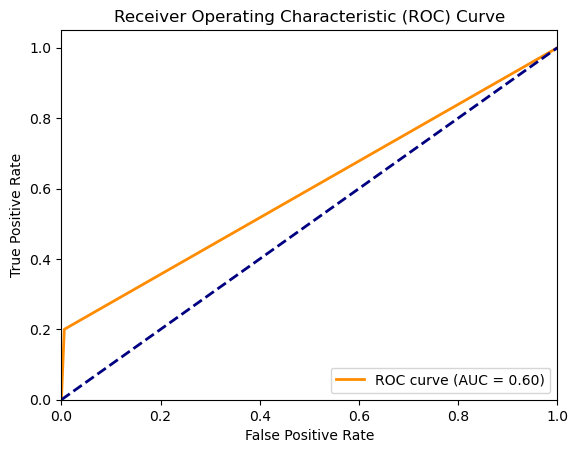

Mean of gpt4: 57.593
CHRG-111hhrg62681
  Agreement: 91.75%
  Disagreement: 8.25%
  Cohen's Kappa: 0.37
 Sum Rater 1: 0.09
 Sum Rater 2: 0.05


Confusion Matrix:
[[431  10]
 [ 30  14]]
Accuracy: 0.92
Precision: 0.58
Recall: 0.32
F1 Score: 0.41


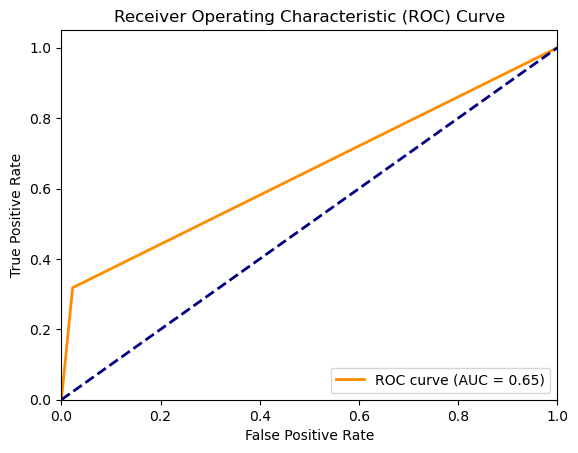

Mean of gpt4: 59.987
CHRG-111hhrg56421
  Agreement: 91.30%
  Disagreement: 8.70%
  Cohen's Kappa: 0.20
 Sum Rater 1: 0.07
 Sum Rater 2: 0.04


Confusion Matrix:
[[827  26]
 [ 54  13]]
Accuracy: 0.91
Precision: 0.33
Recall: 0.19
F1 Score: 0.25


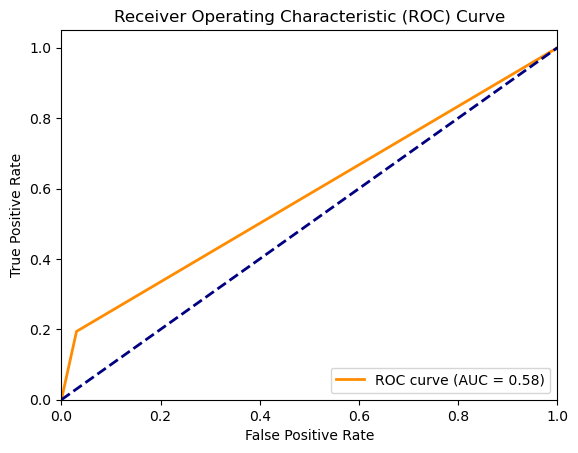

Mean of gpt4: 59.535
CHRG-111hhrg49951
  Agreement: 91.30%
  Disagreement: 8.70%
  Cohen's Kappa: 0.36
 Sum Rater 1: 0.11
 Sum Rater 2: 0.03


Confusion Matrix:
[[559   4]
 [ 51  18]]
Accuracy: 0.91
Precision: 0.82
Recall: 0.26
F1 Score: 0.40


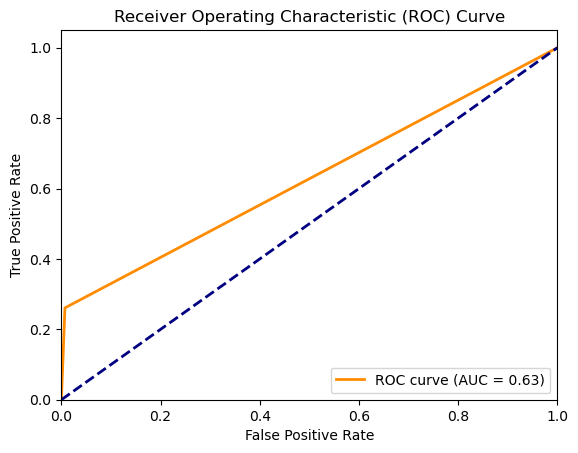

Mean of gpt4: 60.165
CHRG-105hhrg38711
  Agreement: 74.92%
  Disagreement: 25.08%
  Cohen's Kappa: 0.04
 Sum Rater 1: 0.15
 Sum Rater 2: 0.15


Confusion Matrix:
[[716 125]
 [124  28]]
Accuracy: 0.75
Precision: 0.18
Recall: 0.18
F1 Score: 0.18


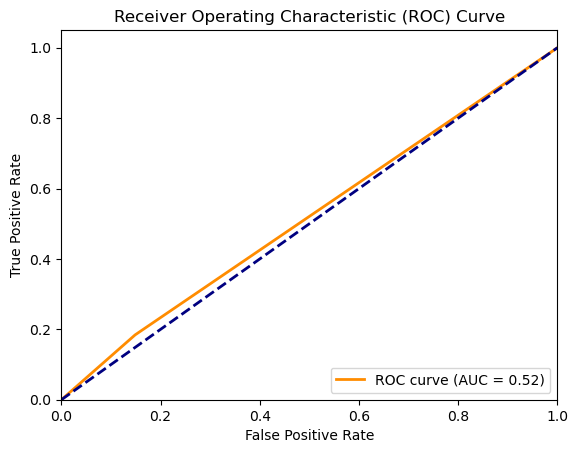

Mean of gpt-4o: 51.779
CHRG-109hhrg98564
  Agreement: 82.34%
  Disagreement: 17.66%
  Cohen's Kappa: 0.11
 Sum Rater 1: 0.07
 Sum Rater 2: 0.15


Confusion Matrix:
[[445  70]
 [ 28  12]]
Accuracy: 0.82
Precision: 0.15
Recall: 0.30
F1 Score: 0.20


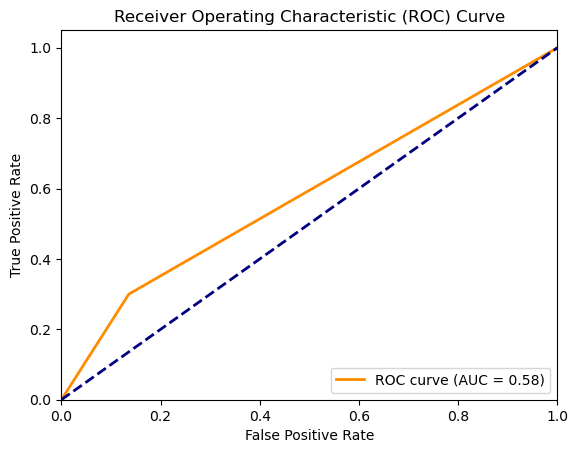

Mean of gpt-4o: 54.991
CHRG-111hhrg62681
  Agreement: 85.77%
  Disagreement: 14.23%
  Cohen's Kappa: 0.28
 Sum Rater 1: 0.09
 Sum Rater 2: 0.13


Confusion Matrix:
[[397  44]
 [ 25  19]]
Accuracy: 0.86
Precision: 0.30
Recall: 0.43
F1 Score: 0.36


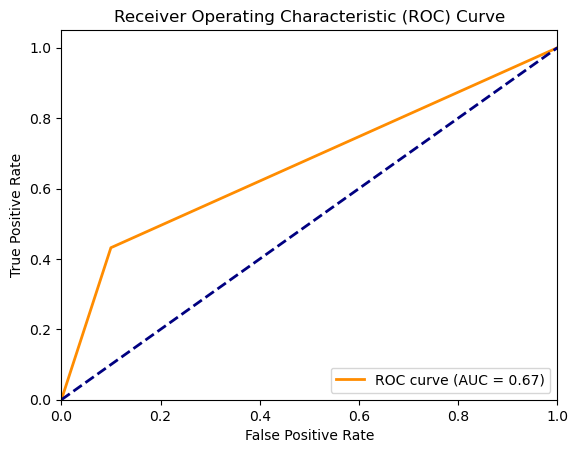

Mean of gpt-4o: 58.862
CHRG-111hhrg56421
  Agreement: 81.30%
  Disagreement: 18.70%
  Cohen's Kappa: 0.12
 Sum Rater 1: 0.07
 Sum Rater 2: 0.16


Confusion Matrix:
[[725 128]
 [ 44  23]]
Accuracy: 0.81
Precision: 0.15
Recall: 0.34
F1 Score: 0.21


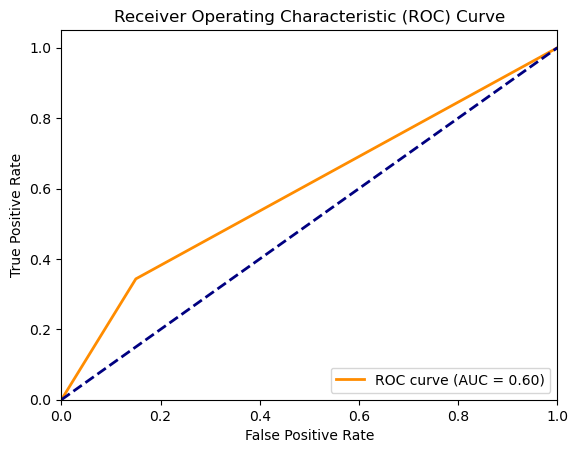

Mean of gpt-4o: 59.062
CHRG-111hhrg49951
  Agreement: 74.05%
  Disagreement: 25.95%
  Cohen's Kappa: 0.12
 Sum Rater 1: 0.11
 Sum Rater 2: 0.24


Confusion Matrix:
[[441 122]
 [ 42  27]]
Accuracy: 0.74
Precision: 0.18
Recall: 0.39
F1 Score: 0.25


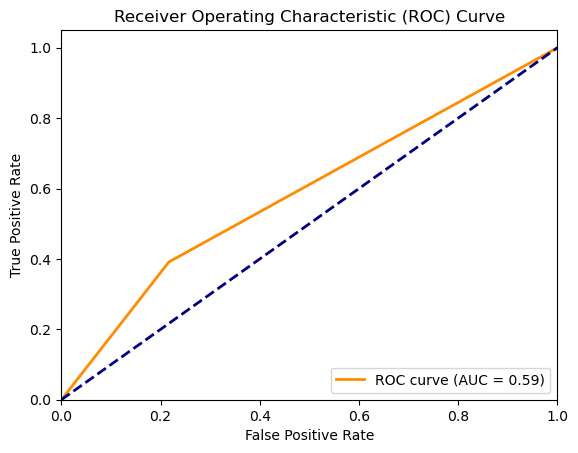

Mean of gpt-4o: 58.995


In [92]:
# Generate the hearing list dynamically
hearing_list = [
    f[:-4] for f in os.listdir(project_path("hearings_testing"))
    if f.startswith("CHRG") and f.endswith(".csv") and "_classified_sentcontext" not in f
]

method_list = ["gpt4","gpt-4o"]

for method in method_list:
    roc_auc_dict = {}
    for hearing in hearing_list:
        print(hearing)
        
        # Load the CSV files
        df_rater_ra = pd.read_csv(project_path("hearings_testing", "sample_comparison", f"{hearing}_classified_ra.csv"))
        df_rater_gpt = pd.read_csv(project_path("hearings_testing", "sample_comparison", f"{hearing}_classified_sentcontext_{method}.csv"))
    
        # Drop NA values and reset indices
        df_rater_ra = df_rater_ra.dropna(subset=['empirical_binary'])
        df_rater_gpt = df_rater_gpt.dropna(subset=['empirical_binary'])
    
        # Merge on common rows based on a unique identifier, e.g., "target_sentence"
        merged_df = pd.merge(df_rater_ra, df_rater_gpt, on="target_sentence", suffixes=('_rater1', '_rater2'))
    
        # Check if there are common rows to compare
        if merged_df.empty:
            print(f"No common rows found for {hearing}. Skipping.")
            continue
    
        # Output agreements and calculate ROC AUC
        output_binary_agreement(merged_df)
        roc_auc = sample_compare(merged_df)
        #output_category_agreement(merged_df)
    
        # Store the ROC AUC score in the dictionary
        roc_auc_dict[hearing] = roc_auc
        mean_value = np.mean(list(roc_auc_dict.values()))
        print(f"Mean of {method}:", round(mean_value*100,3))
        

# Fine Tune

In [ ]:
system_message = "You are a helpful recipe assistant. You are to extract the generic ingredients from each of the recipes provided."


def create_user_message(row):
    return f"Title: {row['title']}\n\nIngredients: {row['ingredients']}\n\nGeneric ingredients: "


def prepare_example_conversation(row):
    return {
        "messages": [
            {"role": "system", "content": system_message},
            {"role": "user", "content": create_user_message(row)},
            {"role": "assistant", "content": row["NER"]},
        ]
    }


training_data = training_df.apply(prepare_example_conversation, axis=1).tolist()

validation_df = recipe_df.loc[101:200]
validation_data = validation_df.apply(
    prepare_example_conversation, axis=1).tolist()

def write_jsonl(data_list: list, filename: str) -> None:
    with open(filename, "w") as out:
        for ddict in data_list:
            jout = json.dumps(ddict) + "\n"
            out.write(jout)


training_file_name = "tmp_recipe_finetune_training.jsonl"
write_jsonl(training_data, training_file_name)

validation_file_name = "tmp_recipe_finetune_validation.jsonl"
write_jsonl(validation_data, validation_file_name)


def upload_file(file_name: str, purpose: str) -> str:
    with open(file_name, "rb") as file_fd:
        response = client.files.create(file=file_fd, purpose=purpose)
    return response.id


training_file_id = upload_file(training_file_name, "fine-tune")
validation_file_id = upload_file(validation_file_name, "fine-tune")

print("Training file ID:", training_file_id)
print("Validation file ID:", validation_file_id)


MODEL = "gpt-4o-mini-2024-07-18"

response = client.fine_tuning.jobs.create(
    training_file=training_file_id,
    validation_file=validation_file_id,
    model=MODEL,
    suffix="recipe-ner",
)

job_id = response.id

print("Job ID:", response.id)
print("Status:", response.status)

response = client.fine_tuning.jobs.retrieve(job_id)

print("Job ID:", response.id)
print("Status:", response.status)
print("Trained Tokens:", response.trained_tokens)

response = client.fine_tuning.jobs.list_events(job_id)

events = response.data
events.reverse()

for event in events:
    print(event.message)

response = client.fine_tuning.jobs.retrieve(job_id)
fine_tuned_model_id = response.fine_tuned_model

if fine_tuned_model_id is None:
    raise RuntimeError(
        "Fine-tuned model ID not found. Your job has likely not been completed yet."
    )

print("Fine-tuned model ID:", fine_tuned_model_id)

test_df = recipe_df.loc[201:300]
test_row = test_df.iloc[0]
test_messages = []
test_messages.append({"role": "system", "content": system_message})
user_message = create_user_message(test_row)
test_messages.append({"role": "user", "content": user_message})

pprint(test_messages)

response = client.chat.completions.create(
    model=fine_tuned_model_id, messages=test_messages, temperature=0, max_tokens=500
)
print(response.choices[0].message.content)

# split into sentences

In [9]:
import nltk
from nltk.tokenize import sent_tokenize
import os
import pandas as pd
import re
from pathlib import Path
import spacy


# Function to count the number of tokens in the text (you can replace this with actual tokenizer)
def count_tokens(text):
    return len(text.split())  # Basic token count, replace with more accurate method if needed

# Function to split the text into chunks of max_tokens
def split_into_chunks(text, max_tokens=500):
    tokens = text.split()
    return [' '.join(tokens[i:i + max_tokens]) for i in range(0, len(tokens), max_tokens)]

# Load the spaCy English model
nlp = spacy.load('en_core_web_sm')

# Function to split the text into sentences using spaCy
def split_into_sentences(text):
    doc = nlp(text)
    return [sent.text for sent in doc.sents]  # Return a list of sentence strings

# Function to create a structured context window of <context_before> <target_sentence> <context_after>
def create_context_window(sentences, index):
    target_sentence = sentences[index]
    
    # Handle first and last sentence cases
    context_before = sentences[index - 1] if index > 0 else ""
    context_after = sentences[index + 1] if index < len(sentences) - 1 else ""
    
    # Return the structured context: <context_before> <target_sentence> <context_after>
    return context_before, target_sentence, context_after

# Updated classify function that processes each sentence with a structured context window
def split_sentences(row):
    speech = row['speech']
    
    # Split the speech into sentences
    sentences = split_into_sentences(speech)
    
    rows = []  # To store all the rows for each context window
    
    for i in range(len(sentences)):
        # Create the structured context window for each sentence
        context_before, target_sentence, context_after = create_context_window(sentences, i)
        
        # Append a new row for this context window, preserving the original columns
        context_row = row.copy()  # Copy the original row to preserve other columns
        context_row['context_before'] = context_before
        context_row['target_sentence'] = target_sentence
        context_row['context_after'] = context_after
        
        rows.append(context_row)
    
    # Return the rows for this speech (one row for each context window)
    return rows

# Function that processes each speech and expands the DataFrame
def process_speech_df(df):
    expanded_rows = []
    
    # Process each row in the original DataFrame
    for index, row in df.iterrows():
        new_rows = split_sentences(row)
        expanded_rows.extend(new_rows)
    
    # Create a new DataFrame from the expanded rows
    expanded_df = pd.DataFrame(expanded_rows)
    return expanded_df

In [1]:
# # Generate the hearing list dynamically
# hearing_list = [
#     f[:-4] for f in os.listdir(project_path("data"))
#     if f.startswith("CHRG") and f.endswith(".csv") and "_sentcontext" not in f
# ]

# counter = 0
# for hearing in hearing_list:
#     output_file = project_path("data", f"{hearing}_sentcontext.csv")
    
#     # Check if the file already exists
#     if os.path.exists(output_file):
#         print(f"Skipping {hearing}: already processed.")
#         continue
    
#     print(f"Processing {hearing}...")
#     # Load the CSV file
#     df = pd.read_csv(project_path("data", f"{hearing}.csv"))
    
#     # Process the DataFrame to expand rows based on sentence context windows
#     expanded_df = process_speech_df(df)
    
#     # Save the processed DataFrame
#     expanded_df.to_csv(output_file, index=False)
#     print(f"Saved {output_file}.")
#     counter += 1
#     print(counter)

In [10]:
hearing_list = [
    f[:-4] for f in os.listdir(project_path("data"))
    if f.startswith("CHRG") and f.endswith(".csv") and "_sentcontext" not in f
]

In [14]:
# Initialize an empty list to hold DataFrames
dfs = []

# Load each file and append its DataFrame to the list
for file_name in hearing_list:
    file_path = os.path.join(project_path("data"), f"{file_name}_sentcontext.csv")
    df = pd.read_csv(file_path)
    dfs.append(df)

# Merge all DataFrames into one
merged_df = pd.concat(dfs, ignore_index=True)

In [21]:
# Define the file path for the pickle file
pickle_file = project_path("data","merged_hearings.pkl")

# Save the DataFrame using pickle
with open(pickle_file, "wb") as file:
    pickle.dump(merged_df, file)

In [5]:
df = pd.read_pickle(project_path("data","merged_hearings_roberta_predict.pkl"))

In [69]:
####
# using documentation from https://github.com/unitedstates/congress/wiki/bills
# downloaded files from https://www.propublica.org/datastore/dataset/congressional-data-bulk-legislation-bills

####

import os
import json

# Function to extract details from a JSON file
def extract_bill_details(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    bill_id = data.get('bill_id')
    official_title = data.get('official_title')
    short_title = data.get('short_title')

    # Extract the last status and corresponding status_at
    actions = data.get('actions', [])
    last_status = None
    last_status_at = None
    for action in actions:
        if 'status' in action and 'acted_at' in action:
            last_status = action['status']
            last_status_at = action['acted_at']

    # Ensure status and status_at are both present
    if last_status and not last_status_at:
        last_status = None

    return {
        'bill_id': bill_id,
        'official_title': official_title,
        'short_title': short_title,
        'status': last_status,
        'status_at': last_status_at
    } if bill_id else None

# Function to process all JSON files in subdirectories
def process_directory(base_dir):
    details_dict = {}

    for subdir, _, files in os.walk(base_dir):
        for file in files:
            if file == 'data.json':
                file_path = os.path.join(subdir, file)
                details = extract_bill_details(file_path)
                if details:
                    details_dict[details['bill_id']] = {
                        'official_title': details['official_title'],
                        'short_title': details.get('short_title'),
                        'status': details.get('status'),
                        'status_at': details.get('status_at')
                    }

    return details_dict

# Main function to handle multiple parent directories and subdirectories
def process_all_directories(base_path, parent_dirs, sub_dirs):
    all_details = {}

    for parent_dir in parent_dirs:
        print(f"Processing Congress {parent_dir}")
        parent_path = os.path.join(base_path, str(parent_dir), "bills")
        for sub_dir in sub_dirs:
            base_dir = os.path.join(parent_path, sub_dir)
            if os.path.exists(base_dir):
                details = process_directory(base_dir)
                all_details.update(details)

    return all_details

# Convert bills_details dictionary to a pandas DataFrame
def create_dataframe(bills_details):
    df = pd.DataFrame.from_dict(bills_details, orient='index')
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'bill_id'}, inplace=True)

    # Add congress column
    df['congress'] = df['bill_id'].apply(lambda x: int(x.split('-')[-1]))

    # Add passed column
    passed_statuses = {'PASS_OVER:HOUSE', 'PASSED:BILL', 'PASS_BACK:HOUSE','ENACTED:SIGNED'}
    df['passed'] = df['status'].apply(lambda x: 1 if x in passed_statuses else 0)

    # Format bill_number while keeping original bill_id
    def format_bill_number(bill_id):
        parts = bill_id.split('-')
        bill_type = "H.R." if parts[0].startswith("hr") else "S."
        bill_number = parts[0][2:] if parts[0].startswith("hr") else parts[0][1:]
        congress = parts[1]
        return f"{congress} {bill_type} {bill_number}"

    df['bill_number'] = df['bill_id'].apply(format_bill_number)

    return df
    
# Define the parameters
base_path = "C:\\Users\\mitha\\Downloads"
parent_directories = range(105, 115)  # Sequential parent directories
subdirectories_of_interest = ["hr", "s"]  # Subdirectories of interest

In [71]:
# Process all directories and collect details
bills_details = process_all_directories(base_path, parent_directories, subdirectories_of_interest)

Processing Congress 105
Processing Congress 106
Processing Congress 107
Processing Congress 108
Processing Congress 109
Processing Congress 110
Processing Congress 111
Processing Congress 112
Processing Congress 113
Processing Congress 114


In [73]:
df_bills = create_dataframe(bills_details)

In [75]:
df_bills

,bill_id,official_title,short_title,status,status_at,congress,passed,bill_number
0,hr1-105,To amend the Fair Labor Standards Act of 1938 ...,Working Families Flexibility Act of 1997,PASS_OVER:HOUSE,1997-03-19T17:24:00-05:00,105,1,105 H.R. 1
1,hr10-105,To enhance competition in the financial servic...,Financial Services Act of 1998,PASS_OVER:HOUSE,1998-05-13T21:12:00-04:00,105,1,105 H.R. 10
2,hr100-105,"To establish the Commonwealth of Guam, and for...",Guam Commonwealth Act,REFERRED,1997-01-07,105,0,105 H.R. 100
3,hr1000-105,To require States to establish a system to pre...,None,PASS_OVER:HOUSE,1997-04-08T17:47:00-04:00,105,1,105 H.R. 1000
4,hr1001-105,To extend the term of appointment of certain m...,None,ENACTED:SIGNED,1997-05-14,105,1,105 H.R. 1001
...,...,...,...,...,...,...,...,...
95581,s995-114,A bill to establish congressional trade negoti...,Bipartisan Congressional Trade Priorities and ...,REPORTED,2015-04-22,114,0,114 S. 995
95582,s996-114,A bill to facilitate nationwide availability o...,Volunteer Income Tax Assistance (VITA) Act,REFERRED,2015-04-16,114,0,114 S. 996
95583,s997-114,A bill to extend the authorization for the maj...,"Department of Veterans Affairs Construction, A...",REFERRED,2015-04-16,114,0,114 S. 997
95584,s998-114,A bill to establish a process for the consider...,American Manufacturing Competitiveness Act of ...,REFERRED,2015-04-16,114,0,114 S. 998


In [77]:
df_bills.to_csv(project_path("data","df_bills.csv"), index=False)

# classify categories with gpt

In [147]:
df = pd.read_pickle(project_path("data","merged_hearings_roberta_predict.pkl"))

In [172]:
df = df.sample(frac=0.001, random_state=42)  # sample for test

In [177]:
# System prompt for the assistant's role
SYSTEM_PROMPT = """
You are a research assistant analyzing congressional hearing transcripts to identify discussions of empirical evidence. Your role is to evaluate a <target sentence>, with the help of a surrounding context window of one sentence before (<context_before>) and one sentence after (<context_after>). Your task is as follows:

1. **Determine if the <target_sentence> mentions empirical evidence**:
   - Empirical evidence is defined as:
     - Information gathered directly or indirectly through observation or experimentation.
     - Evidence that helps confirm, disconfirm, justify, or establish as reasonable a theory, policy, or argument.

2. **Classify empirical evidence into these categories (with examples)**:
   - **Monetary**: Facts about the economy, budgets, or costs.
     - Example: "The costs of Shuttle missions to service Hubble have never been charged to the science program."
   - **Causal**: Statements showing cause-and-effect relationships.
     - Example: "We did so because veterans consistently told us their evidence of toxic exposures was being minimized or ignored."
   - **Descriptive**: Factual descriptions of situations, events, or populations.
     - Example: "There are medical organizations now who are treating tens of thousands of people overdosed with chemicals."
   - **Qualitative**: Non-quantitative observations, interviews, or narratives.
     - Example: "Diverse array of symptoms including fatigue, skin rash, headache, muscle and joint pain, memory problems, shortness of breath, sleep disturbances, gastrointestinal symptoms, and chest pain."
   - **Historical**: References to past events or timelines.
     - Example: "1995 is the point at which you began to ask our troops if they were exposed to chemicals."
   - **Statistical**: Use of statistics, numbers, or comparisons.
     - Example: "Have you encountered--in your study dealing with these servicemen and women, have you encountered that in other instances that you might think would be the higher percentage than average population?"
   - **Other**: If the evidence does not fit into the above categories, specify what it refers to.

3. **Focus only on the <target_sentence>**:
   - Do not consider evidence in <context_before> or <context_after> unless it directly impacts understanding the <target_sentence>.

4. **Respond in a structured format**:
   - *** EMPIRICAL BINARY ***: Indicate "Yes" or "No".
   - *** EMPIRICAL EVIDENCE CATEGORY ***: Classify each quote into one or more categories, separated by " ***** ".
"""

# User prompt for the assistant's task
USER_MESSAGE = """
Analyze the following <target_sentence> for empirical evidence. Follow the instructions and structure your response as follows:

1. *** EMPIRICAL BINARY ***
   - Does the <target_sentence> mention empirical evidence? Answer only "Yes" or "No".

2. *** EMPIRICAL EVIDENCE CATEGORY ***
   - Classify each quote into one or more of the following categories:
     - Monetary, Causal, Descriptive, Qualitative, Historical, Statistical, Other (specify).
   - Separate categories using " ***** ".
   - If there is no empirical evidence, write "None".

Now analyze the following <target_sentence>, keeping your response concise and following the format exactly:
"""
import pandas as pd
import os

# Function to send a message to GPT
def send_message(role_messages, model_choice="gpt-4"):
    response = client.chat.completions.create(
        model=model_choice,
        messages=role_messages,
        temperature=0,
        max_tokens=500,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0
    )
    return response.choices[0].message.content

# Function to parse GPT's response
def parse_assistant_response(assistant_content):
    # Extract the empirical binary part
    binary_start = assistant_content.find('*** EMPIRICAL BINARY ***') + len('*** EMPIRICAL BINARY ***')
    binary_end = assistant_content.find('*** EMPIRICAL EVIDENCE CATEGORY ***')
    empirical_binary = assistant_content[binary_start:binary_end].strip()

    # Extract the empirical categories part
    category_start = assistant_content.find('*** EMPIRICAL EVIDENCE CATEGORY ***') + len('*** EMPIRICAL EVIDENCE CATEGORY ***')
    empirical_category = assistant_content[category_start:].strip().split("*****")

    return empirical_binary, empirical_category

# Function to classify sentences using GPT
def classify_sentence_with_context(row):
    context_before = row['context_before']
    target_sentence = row['target_sentence']
    context_after = row['context_after']
    
    # Build the user message
    user_message_content = f"<context_before> {context_before} </context_before> <target_sentence> {target_sentence} </target_sentence> <context_after> {context_after} </context_after>"
    user_message = {"role": "user", "content": f"{USER_MESSAGE} Speech: {user_message_content}"}
    role_messages = [{"role": "system", "content": SYSTEM_PROMPT}, user_message]
    
    # Send the message to GPT and get the response
    response = send_message(role_messages)
    
    # Parse GPT's response
    empirical_binary, empirical_category = parse_assistant_response(response)
    
    # Add results to the row
    row['empirical_binary_gpt'] = empirical_binary
    row['empirical_category_gpt'] = " ***** ".join(empirical_category)
    
    return row

# Function to process the DataFrame with progress statements and checkpoints
def process_speech_df_with_checkpoints(df, checkpoint_dir="checkpoints", batch_size=50, output_file="processed_results.csv"):
    os.makedirs(checkpoint_dir, exist_ok=True)  # Ensure checkpoint directory exists
    processed_rows = []
    checkpoint_files = []
    
    total_rows = len(df)
    for index, row in enumerate(df.itertuples(), start=1):
        processed_row = classify_sentence_with_context(row._asdict())
        processed_rows.append(processed_row)
        
        # Print progress every batch_size rows
        if index % batch_size == 0 or index == total_rows:
            print(f"Processed {index}/{total_rows} rows ({(index / total_rows) * 100:.2f}%).")
            
            # Save checkpoint
            checkpoint_file = os.path.join(checkpoint_dir, f"checkpoint_{index}.csv")
            pd.DataFrame(processed_rows).to_csv(checkpoint_file, index=False)
            checkpoint_files.append(checkpoint_file)
            
            # Clear memory for the next batch
            processed_rows = []

    # Combine all checkpoints into a final DataFrame
    all_dataframes = [pd.read_csv(file) for file in checkpoint_files]
    final_df = pd.concat(all_dataframes, ignore_index=True)

    # Save final DataFrame
    final_df.to_csv(output_file, index=False)
    print(f"Final results saved to {output_file}.")
    
    # Clean up checkpoint files
    for file in checkpoint_files:
        os.remove(file)
    print(f"Deleted checkpoint files in {checkpoint_dir}.")

    return final_df


In [181]:
final_df = process_speech_df_with_checkpoints(df, batch_size=100)
# Save or analyze the processed DataFrame
processed_df.to_csv(project_path("hearings_testing","processed_results_gpt_robertasampled.csv"), index=False)

Processed 100/5891 rows (1.70%).
Processed 200/5891 rows (3.40%).
Processed 300/5891 rows (5.09%).
Processed 400/5891 rows (6.79%).
Processed 500/5891 rows (8.49%).
Processed 600/5891 rows (10.19%).
Processed 700/5891 rows (11.88%).
Processed 800/5891 rows (13.58%).
Processed 900/5891 rows (15.28%).
Processed 1000/5891 rows (16.98%).
Processed 1100/5891 rows (18.67%).
Processed 1200/5891 rows (20.37%).
Processed 1300/5891 rows (22.07%).
Processed 1400/5891 rows (23.77%).
Processed 1500/5891 rows (25.46%).
Processed 1600/5891 rows (27.16%).
Processed 1700/5891 rows (28.86%).
Processed 1800/5891 rows (30.56%).
Processed 1900/5891 rows (32.25%).
Processed 2000/5891 rows (33.95%).
Processed 2100/5891 rows (35.65%).
Processed 2200/5891 rows (37.35%).
Processed 2300/5891 rows (39.04%).
Processed 2400/5891 rows (40.74%).
Processed 2500/5891 rows (42.44%).
Processed 2600/5891 rows (44.14%).
Processed 2700/5891 rows (45.83%).
Processed 2800/5891 rows (47.53%).
Processed 2900/5891 rows (49.23%).

APIConnectionError: Connection error.

In [122]:
# df = pd.read_csv(project_path("hearings_testing", "processed_results_gpt_robertasampled.csv"))
df = pd.read_csv(project_path("hearings_testing", "processed_results_gpt_agreementdf.csv")) 

df["empirical_category_gpt"] = df["empirical_category_gpt"].fillna("None")

# Step 1: Split by "*****" and clean each category
def clean_and_split_categories(value):
    # Split by "*****"
    categories = value.split("*****")
    # Remove non-letter symbols and strip extra spaces
    cleaned_categories = [re.sub(r"[^a-zA-Z]", "", cat).strip() for cat in categories]
    # Filter out empty strings
    return [cat for cat in cleaned_categories if cat]

# Apply cleaning and splitting
df["cleaned_categories"] = df["empirical_category_gpt"].apply(clean_and_split_categories)

# Step 2: Create `empirical_binary_gpt` (1 if there are categories, 0 if empty or "None")
df["empirical_binary_gpt"] = df["cleaned_categories"].apply(lambda x: 0 if "None" in x else 1)

# Step 3: One-hot encode categories
categories = ["Causal", "Descriptive", "Monetary", "Statistical", "Historical", "Qualitative"]
for category in categories:
    df[f"category_gpt_{category.lower()}"] = df["cleaned_categories"].apply(
        lambda x: 1 if category in x else 0
    )

# Drop the temporary columns
df['empirical_category_gpt'] = df['cleaned_categories']
df.drop(['cleaned_categories'], axis=1, inplace=True)

In [126]:
# process the RA categories

df['empirical_category_cleaned'] = df['empirical_category'] \
    .str.replace(' ', '') \
    .str.replace('.', '') \
    .str.lower()

# Split the cleaned 'Category' column by comma
df['empirical_category_split'] = df['empirical_category_cleaned'].str.split(',')

df['empirical_category_split'] = df['empirical_category_split'].apply(
    lambda x: x if isinstance(x, (list, set)) else []
)

# Get the list of all unique categories
unique_categories = set()

# Safely update unique_categories with iterables
df['empirical_category_split'].apply(lambda x: unique_categories.update(x))


# Create one-hot encoded columns
for category in unique_categories:
    df[f'category_ra_{category}'] = df['empirical_category_split'].apply(
        lambda x: 1 if category in x else 0
    )

# Drop the temporary columns
df.drop(['empirical_category_cleaned', 'empirical_category_split'], axis=1, inplace=True)

df['empirical_binary_ra'] = df['empirical_binary']

In [140]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a function to evaluate performance for a binary variable
def evaluate_binary(y_true, y_pred, label):
    metrics = {
        "label": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

# Create a list to store results
results = []

# Evaluate the binary variable
binary_metrics = evaluate_binary(
    df["empirical_binary_ra"],  # Human baseline
    df["empirical_binary_gpt"],  # GPT predictions
    label="empirical_binary"
)
results.append(binary_metrics)

# Evaluate each one-hot encoded category
categories = ["causal", "descriptive", "monetary", "statistical", "historical", "qualitative"]

for category in categories:
    ra_col = f"category_ra_{category}"
    gpt_col = f"category_gpt_{category}"
    
    # Evaluate the category
    category_metrics = evaluate_binary(
        df[ra_col],  # Human baseline for this category
        df[gpt_col],  # GPT predictions for this category
        label=f"category_{category}"
    )
    results.append(category_metrics)

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

# Display the results
print(results_df)

# Calculate the macro-average for numerical columns only
macro_metrics = results_df.drop(columns=["label"]).mean()  # Exclude the label column
print("\nMacro-average performance for categories:")
print(macro_metrics)

                  label  accuracy  precision    recall  f1_score
0      empirical_binary  0.913111   0.598592  0.755556  0.667976
1       category_causal  0.978920   0.371429  0.406250  0.388060
2  category_descriptive  0.912596   0.526012  0.508380  0.517045
3     category_monetary  0.978406   0.412698  0.838710  0.553191
4  category_statistical  0.979949   0.136364  0.857143  0.235294
5   category_historical  0.960411   0.064935  0.500000  0.114943
6  category_qualitative  0.986632   0.217391  0.384615  0.277778

Macro-average performance for categories:
accuracy     0.958575
precision    0.332489
recall       0.607236
f1_score     0.393470
dtype: float64


In [144]:
import numpy as np

# Example: Replace with your actual category list
categories = ["causal", "descriptive", "monetary", "statistical", "historical", "qualitative"]

# Store metrics for categories
weighted_metrics = {
    "precision": 0,
    "recall": 0,
    "f1_score": 0
}

# Total number of ground-truth positive samples across all categories
total_samples = 0

# Loop through each category to calculate weighted metrics
for category in categories:
    # Ground-truth positives for the category
    num_positives = df[f"category_ra_{category}"].sum()
    total_samples += num_positives

    # Get precision, recall, and F1 score for the category from `results_df`
    precision = results_df.loc[results_df["label"] == f"category_{category}", "precision"].values[0]
    recall = results_df.loc[results_df["label"] == f"category_{category}", "recall"].values[0]
    f1_score = results_df.loc[results_df["label"] == f"category_{category}", "f1_score"].values[0]

    # Accumulate weighted metrics
    weighted_metrics["precision"] += precision * num_positives
    weighted_metrics["recall"] += recall * num_positives
    weighted_metrics["f1_score"] += f1_score * num_positives

# Normalize by the total number of samples
for metric in weighted_metrics:
    weighted_metrics[metric] /= total_samples

# Display weighted averages
print("Weighted averages for categories:")
print(weighted_metrics)

Weighted averages for categories:
{'precision': 0.45318168199979697, 'recall': 0.5367647058823529, 'f1_score': 0.47252050810149687}


In [39]:
# Define the directory containing the checkpoint files
checkpoint_dir = Path(project_path("scripts", "checkpoints"))

# Get all checkpoint files
csv_files = sorted(checkpoint_dir.glob("checkpoint_*.csv"))  # Sorting ensures a logical order

# Load and concatenate all files
df_list = [pd.read_csv(file) for file in csv_files]
merged_df = pd.concat(df_list, ignore_index=True)


In [41]:
def clean(df):
    df["empirical_category_gpt"] = df["empirical_category_gpt"].fillna("None")
    
    # Step 1: Split by "*****" and clean each category
    def clean_and_split_categories(value):
        # Split by "*****"
        categories = value.split("*****")
        # Remove non-letter symbols and strip extra spaces
        cleaned_categories = [re.sub(r"[^a-zA-Z]", "", cat).strip() for cat in categories]
        # Filter out empty strings
        return [cat for cat in cleaned_categories if cat]
    
    # Apply cleaning and splitting
    df["cleaned_categories"] = df["empirical_category_gpt"].apply(clean_and_split_categories)
    
    # Step 2: Create `empirical_binary_gpt` (1 if there are categories, 0 if empty or "None")
    df["empirical_binary_gpt"] = df["cleaned_categories"].apply(lambda x: 0 if "None" in x else 1)
    
    # Step 3: One-hot encode categories
    categories = ["Causal", "Descriptive", "Monetary", "Statistical", "Historical", "Qualitative"]
    for category in categories:
        df[f"category_gpt_{category.lower()}"] = df["cleaned_categories"].apply(
            lambda x: 1 if category in x else 0
        )
    
    # Drop the temporary columns
    df['empirical_category_gpt'] = df['cleaned_categories']
    df.drop(['cleaned_categories'], axis=1, inplace=True)

    return df

In [42]:
merged_df = clean(merged_df)

In [45]:
merged_df.columns

Index(['Index', 'congress', 'committee_code2', 'title', 'file_name',
       'thomas_name', 'govtrack', 'speech', 'rownumber', 'gscore', 'powercmt',
       'security', 'year', 'minority', 'unified', 'minuni', 'partyloyalty',
       'votepct100', 'votepct_sq100', 'seniority_rs', 'seniority_sq_rs',
       'abs_dwnom1_rs', 'dem', 'freshman', 'female', 'chairspeech',
       'rankmemspeech', 'leader', 'salience', 'salience_rs', 'polar',
       'polar_rs', 'context_before', 'target_sentence', 'context_after',
       'predictions', 'probabilities', 'empirical_binary_gpt',
       'empirical_category_gpt', 'category_gpt_causal',
       'category_gpt_descriptive', 'category_gpt_monetary',
       'category_gpt_statistical', 'category_gpt_historical',
       'category_gpt_qualitative'],
      dtype='object')

In [49]:
merged_df['category_gpt_descriptive'].mean()/

0.13833333333333334

causal         0.02
descriptive    0.14
monetary       0.05
statistical    0.03
historical     0.06
qualitative    0.01
dtype: float64


C:\Users\mitha\AppData\Local\Temp\ipykernel_4100\1327071583.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Share', data=category_shares_df, palette='viridis')


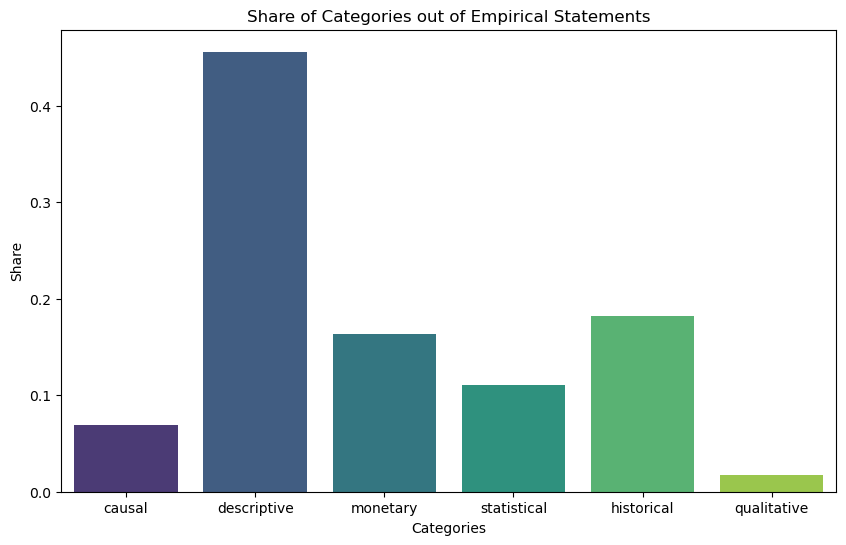

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Specify the columns you want to plot (without "category_gpt_")
columns_to_plot = ['causal', 'descriptive', 'monetary', 'statistical', 'historical', 'qualitative']

# Rename columns in the DataFrame
renamed_columns = {f'category_gpt_{col}': col for col in columns_to_plot}
merged_df = merged_df.rename(columns=renamed_columns)

# Calculate the sum of the specified columns
category_sums = merged_df[columns_to_plot].sum()
print(merged_df[columns_to_plot].mean().round(2))
print(merged_df[columns_to_plot].mean().round(2))


# Normalize the sums to get the share
total_sum = category_sums.sum()
category_shares = category_sums / total_sum

# Convert the shares to a DataFrame for seaborn
category_shares_df = category_shares.reset_index()
category_shares_df.columns = ['Category', 'Share']

# Plot the distribution using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Share', data=category_shares_df, palette='viridis')
plt.title('Share of Categories out of Empirical Statements')
plt.xlabel('Categories')
plt.ylabel('Share')
plt.xticks(rotation=0)
#plt.show()
plt.savefig(project_path('plots','categories_count.png'),bbox_inches='tight')  # save the figure to file

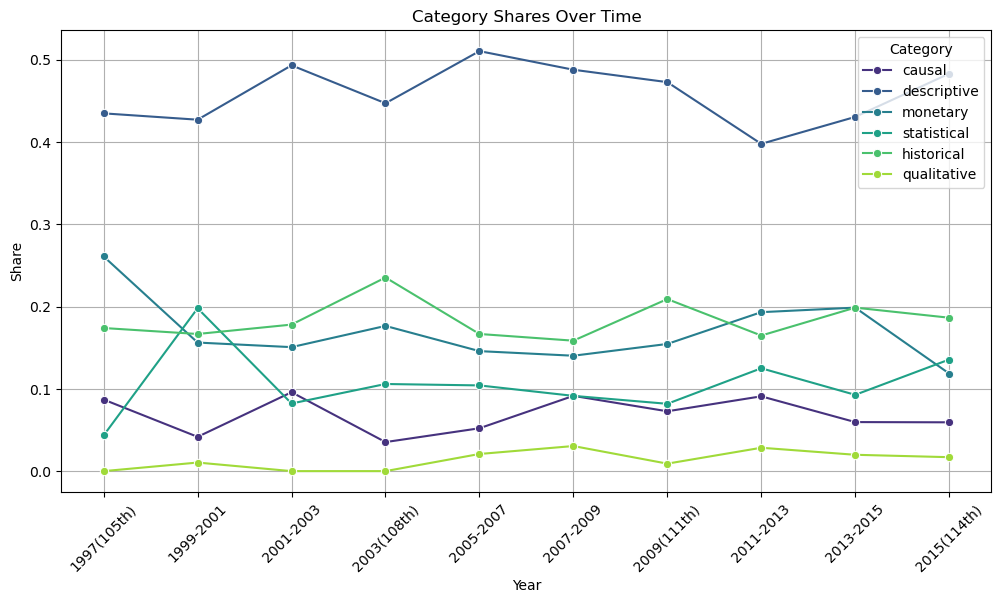

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and sum each category
category_sums_by_year = merged_df.groupby('year')[columns_to_plot].sum()

# Normalize by row sum to get category shares per year
category_shares_by_year = category_sums_by_year.div(category_sums_by_year.sum(axis=1), axis=0)

# Reset index for plotting
category_shares_by_year = category_shares_by_year.reset_index()

# Plot category shares over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=category_shares_by_year.melt(id_vars='year', var_name='Category', value_name='Share'),
             x='year', y='Share', hue='Category', marker='o', palette='viridis')

plt.title('Category Shares Over Time')
plt.xlabel('Year')
plt.ylabel('Share')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.grid(True)
plt.show()


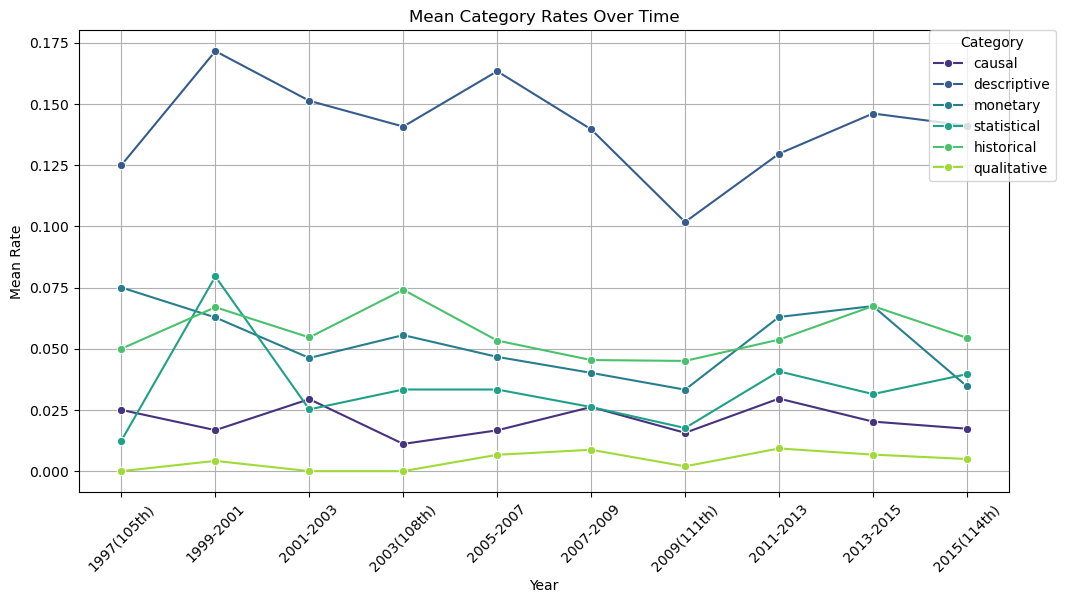

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and compute the mean (proportion of documents per year)
category_means_by_year = merged_df.groupby('year')[columns_to_plot].mean()

# Reset index for plotting
category_means_by_year = category_means_by_year.reset_index()

# Plot mean category rates over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=category_means_by_year.melt(id_vars='year', var_name='Category', value_name='Mean Rate'),
             x='year', y='Mean Rate', hue='Category', marker='o', palette='viridis')

plt.title('Mean Category Rates Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Rate')
plt.xticks(rotation=45)
plt.legend(title='Category', loc='upper right', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.grid(True)
plt.show()


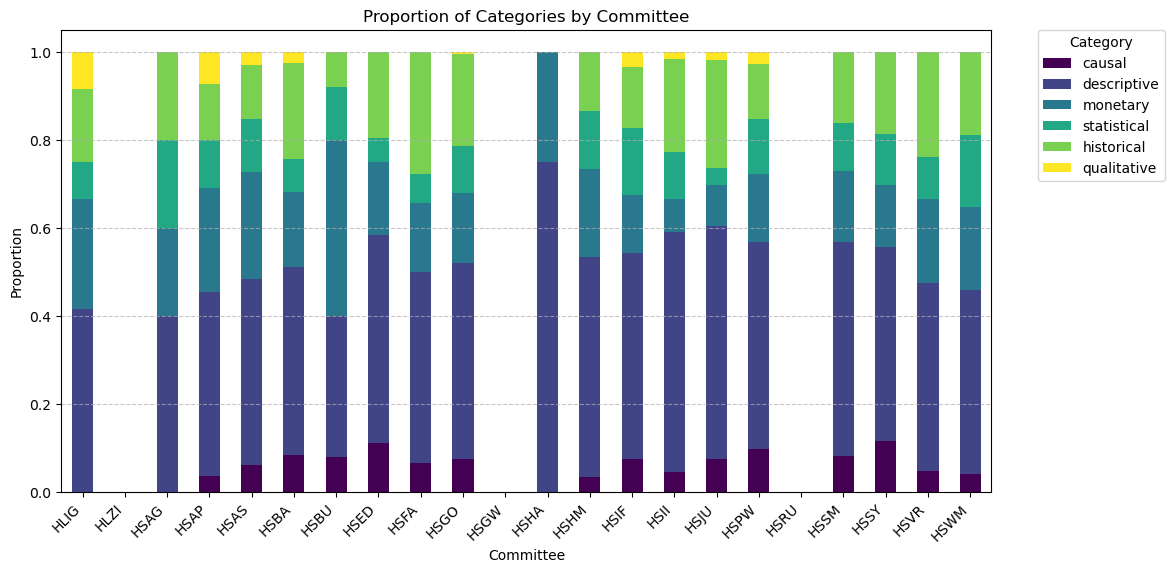

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by committee and sum each category
category_sums_by_committee = merged_df.groupby('committee_code2')[columns_to_plot].sum()

# Normalize to get proportions
category_shares_by_committee = category_sums_by_committee.div(category_sums_by_committee.sum(axis=1), axis=0)

# Plot stacked bar chart
category_shares_by_committee.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

# Formatting
plt.title('Proportion of Categories by Committee')
plt.xlabel('Committee')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


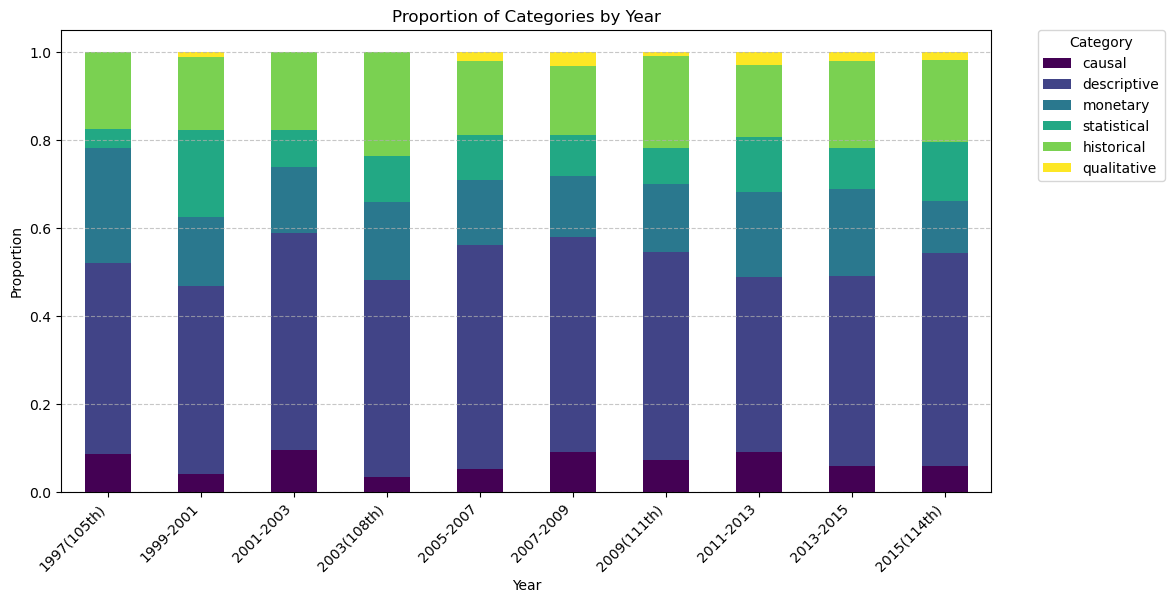

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by committee and sum each category
category_sums_by_committee = merged_df.groupby('year')[columns_to_plot].sum()

# Normalize to get proportions
category_shares_by_committee = category_sums_by_committee.div(category_sums_by_committee.sum(axis=1), axis=0)

# Plot stacked bar chart
category_shares_by_committee.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

# Formatting
plt.title('Proportion of Categories by Year')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


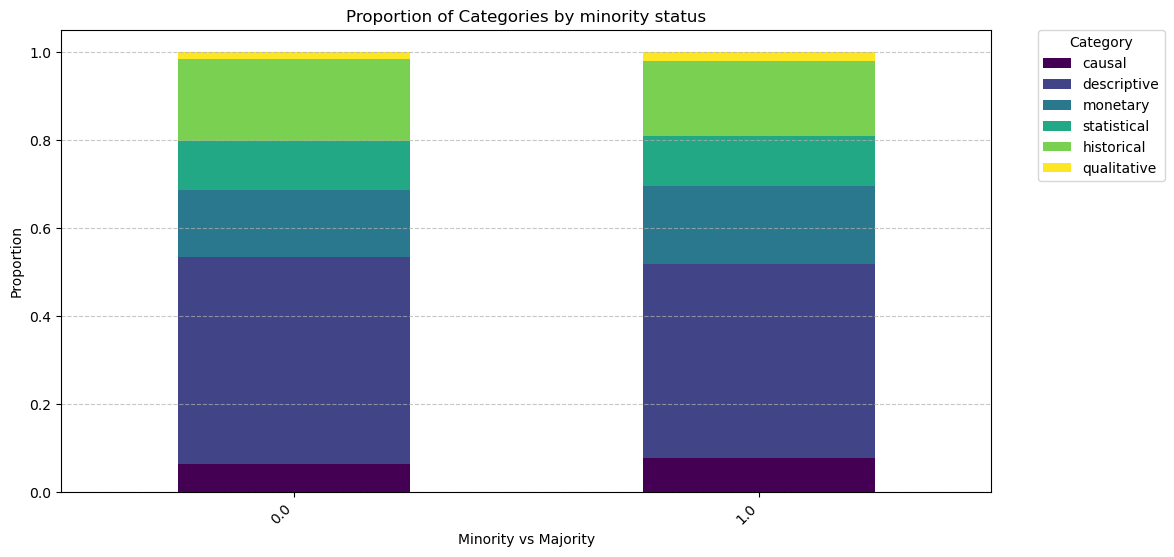

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by committee and sum each category
category_sums_by_committee = merged_df.groupby('minority')[columns_to_plot].sum()

# Normalize to get proportions
category_shares_by_committee = category_sums_by_committee.div(category_sums_by_committee.sum(axis=1), axis=0)

# Plot stacked bar chart
category_shares_by_committee.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

# Formatting
plt.title('Proportion of Categories by minority status')
plt.xlabel('Minority vs Majority')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


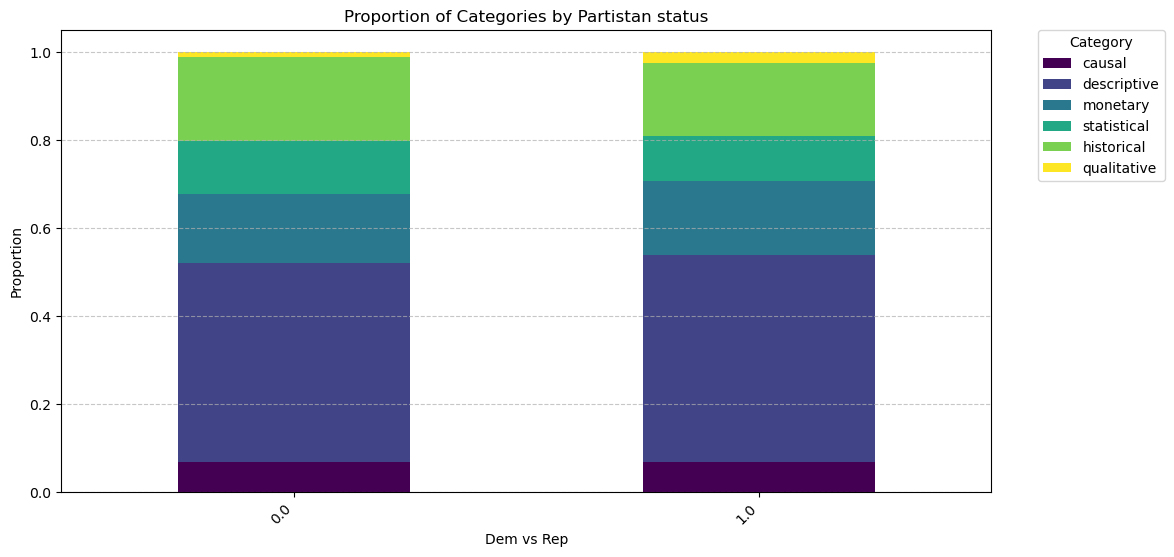

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by committee and sum each category
category_sums_by_committee = merged_df.groupby('dem')[columns_to_plot].sum()

# Normalize to get proportions
category_shares_by_committee = category_sums_by_committee.div(category_sums_by_committee.sum(axis=1), axis=0)

# Plot stacked bar chart
category_shares_by_committee.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

# Formatting
plt.title('Proportion of Categories by Partistan status')
plt.xlabel('Dem vs Rep')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()